<a href="https://colab.research.google.com/github/dazzens/ecommerce-sales-analysis/blob/main/ecommerce-sales-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

------------------
---------
-----

# **Анализ продаж и возвратов интернет-магазина**




Автор: А.Г.Х.

- Начало: 22.06.2026
- Окончание: 16.08.2026

- Инструменты: **Python, pandas, NumPy, Matplotlib, Seaborn, Jupyter Notebook**
----



##**Бизнес-контекст**

Датасет содержит транзакции британского интернет-магазина подарков и товаров для дома за один год. Покупатели представлены в Великобритании и других странах. Исследование направлено на анализ денежных показателей операций, ассортимента, поведения клиентов и географии продаж.



-----

# **Цель исследования**

Оценить динамику и структуру продаж интернет-магазина, определить зоны концентрации выручки и возвратов и сформулировать рекомендации.

## **Вопросы исследования**

1. Как менялись сумма продаж и количество заказов по месяцам?
2. Какие товары лидируют по выручке, количеству проданных единиц и числу заказов?
3. Как распределены сумма заказа и состав корзины?
4. Как продажи распределены между странами?
5. Насколько выручка зависит от отдельных клиентов?
6. Какие товары формируют наибольшую сумму возвратов?
7. Как продажи распределены между ценовыми интервалами?



## **Содержание проекта**



1.  **Первичный осмотр и подготовка данных**
    *   Импорт библиотек и загрузка данных.
    *   Предварительный анализ структуры данных (типы, объем, пропуски).
    *   Преобразование типов данных (`Date` в `datetime`, `CustomerNo` в `int`).
    *   Проверка и обработка пропусков (`CustomerNo`).
    *   Проверка дубликатов и выбросов (`Price`, `Quantity`).

2.  **Предварительный анализ и создание новых признаков**
    *   Расчет общих метрик (общая выручка, количество заказов, количество клиентов, средний чек).
    *   Создание признаков: месяц, день недели, год из даты.
    *   Создание признака: общая сумма заказа (`Price` x `Quantity`).
    *   Агрегация данных на уровне заказа (`TransactionNo`) для анализа корзины.

3.  **Исследовательский анализ данных (EDA)**
    *   Анализ динамики продаж: выручка и количество заказов по месяцам, сезонность.
    *   Анализ товаров: топ-10 по выручке, топ-10 по количеству продаж, распределение цен.
    *   Анализ корзины: среднее количество товаров в заказе, средний чек, распределение заказов по сумме.
    *   Анализ клиентов: топ-10 по сумме трат, топ-10 по частоте покупок, новые, повторные клиенты.
    *   Географический анализ: выручка и количество заказов по странам, средний чек по странам.
    *   Анализ ценовых сегментов: зависимость количества продаж от цены.

4.  **Ключевые выводы и рекомендации**
    *   Формирование основных инсайтов по каждому блоку анализа.
    *   Разработка практических рекомендаций для увеличения выручки, удержания клиентов и оптимизации ассортимента.


    

## **Описание данных**

Источник: [An Online Shop Business — Kaggle](https://www.kaggle.com/datasets/gabrielramos87/an-online-shop-business).

| Поле | Описание | Исходный тип |
|---|---|---|
| `TransactionNo` | Идентификатор транзакции | `object` |
| `Date` | Дата транзакции | `object` |
| `ProductNo` | Идентификатор товара | `object` |
| `ProductName` | Название товара | `object` |
| `Price` | Цена единицы товара, £ | `float64` |
| `Quantity` | Количество единиц в строке транзакции | `int64` |
| `CustomerNo` | Идентификатор клиента | `float64` |
| `Country` | Страна клиента | `object` |

Исходный набор содержит 536 350 строк, 4 738 идентифицированных клиентов, 3 768 товаров и 38 стран. В 55 строках отсутствует `CustomerNo`.



---

**Характеристики данных:**

|  |  |
|------------|----------|
| **Объем данных** | 536 350 записей |
| **Количество клиентов** | 4 738 |
| **Количество уникальных товаров** | 3 768 |
| **Количество стран** | 38 |
| **Пропуски** | 55 записей без `CustomerNo` (0.01%) |



## **Правила расчёта**

| Показатель | Определение |
|---|---|
| Продажа | Строка с `Quantity > 0` |
| Возвратная/отменённая операция | Строка с `Quantity < 0` и префиксом `C` в `TransactionNo` |
| Валовая выручка | Сумма `Price × Quantity` по продажам |
| Сумма возвратов | Сумма `Price × |Quantity|` по отрицательным операциям |
| Нетто-сумма | Валовая выручка минус сумма возвратов |
| Заказ | Уникальный `TransactionNo` среди продаж |
| Средний чек | Валовая выручка / число заказов |

Термин «возврат» используется как сокращение для отрицательных операций; исходные данные не содержат отдельного поля с причиной отмены или возврата.


## **Краткий результат**

- Сумма продаж за период наблюдения — **£62,78 млн**, возвратных и отменённых операций — **£2,66 млн**, нетто-сумма — **£60,12 млн**.
- Великобритания формирует **83,38%** валовой выручки и **90,49%** заказов.
- Верхние 10% клиентов формируют **59,02%** валовой выручки.
- Два товара формируют **50,46%** суммы возвратных операций.

Результаты показывают концентрацию операций, но не устанавливают причины и не заменяют проверку маржинальности, каналов привлечения и долгосрочного удержания.


----
----

# **Этап 1 Первичный осмотр и подготовка данных**

- Импорт библиотек и загрузка данных.
- Предварительный анализ структуры данных (типы, объем, пропуски).
- Преобразование типов данных
- Проверка и обработка пропусков
- Проверка дубликатов и выбросов



## **Шаг 1.1. Загрузка данных**

* Подключение библиотек и загрузка  CSV-файла из открытого источника.

---
### **Библиотеки**




In [ ]:
# Загруза библиотек

try:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from matplotlib.ticker import FuncFormatter
    import seaborn as sns
    import kagglehub
    import os
    print("Все библиотеки загружены")

except ImportError:
    !pip install numpy pandas matplotlib seaborn   kagglehub -q
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from matplotlib.ticker import FuncFormatter
    import seaborn as sns
    import kagglehub
    import os
    print("Библиотеки загружены через pip")






Все библиотеки загружены


### **Загрузка датасета**

In [ ]:
# Загрузка датасета

path = kagglehub.dataset_download("gabrielramos87/an-online-shop-business")
file_path = os.path.join(path, [x for x in os.listdir(path) if x.endswith('.csv')][0])

# Сохранение

df = pd.read_csv(file_path)



100%|██████████| 6.66M/6.66M [00:00<00:00, 178MB/s]

Extracting files...


**Итого:** библиотеки подключены, исходные данные загружены в датафрейм `df`.

-----
----
----

## **Шаг 1.2. Общий осмотр данных**

Первичный анализ структуры данных, таких как:

- размерность датасета
- типы признаков и их соответствие содержанию
- наличие пропусков и их доля в каждом поле
- основные статистические характеристики числовых переменных

In [ ]:
# Основная информация

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536350 entries, 0 to 536349
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionNo  536350 non-null  object 
 1   Date           536350 non-null  object 
 2   ProductNo      536350 non-null  object 
 3   ProductName    536350 non-null  object 
 4   Price          536350 non-null  float64
 5   Quantity       536350 non-null  int64  
 6   CustomerNo     536295 non-null  float64
 7   Country        536350 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 32.7+ MB


In [ ]:
# Вывод первых 10 строк

df.head(10)

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
0,581482,12/9/2019,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom
1,581475,12/9/2019,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom
2,581475,12/9/2019,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom
3,581475,12/9/2019,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069.0,United Kingdom
4,581475,12/9/2019,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069.0,United Kingdom
5,581475,12/9/2019,21705,Bag 500g Swirly Marbles,10.65,24,13069.0,United Kingdom
6,581475,12/9/2019,22118,Joy Wooden Block Letters,11.53,18,13069.0,United Kingdom
7,581475,12/9/2019,22119,Peace Wooden Block Letters,12.25,12,13069.0,United Kingdom
8,581475,12/9/2019,22217,T-Light Holder Hanging Lace,10.65,12,13069.0,United Kingdom
9,581475,12/9/2019,22216,T-Light Holder White Lace,10.55,24,13069.0,United Kingdom


In [ ]:
# Осмотр случайных строк

df.sample(10)

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
107012,574075,11/2/2019,22739,Ribbon Reel Christmas Sock Bauble,11.94,5,16365.0,United Kingdom
263868,560926,7/22/2019,85123A,Cream Hanging Heart T-Light Holder,16.18,3,17926.0,United Kingdom
347845,553175,5/15/2019,22149,Feltcraft 6 Flower Friends,12.40,2,16175.0,United Kingdom
468405,541987,1/24/2019,21527,Red Retrospot Traditional Teapot,18.40,2,14130.0,United Kingdom
504576,538991,12/15/2018,22610,Pens Assorted Funny Face,10.47,72,17511.0,United Kingdom
106926,574074,11/2/2019,82583,Hot Baths Metal Sign,14.48,1,17074.0,United Kingdom
161531,569641,10/5/2019,21213,Pack Of 72 Skull Cake Cases,10.81,24,12841.0,United Kingdom
467570,541880,1/24/2019,20726,Lunch Bag Woodland,5.97,20,13819.0,United Kingdom
487997,540418,1/7/2019,84029G,Knitted Union Flag Hot Water Bottle,18.06,1,14418.0,United Kingdom
88033,575221,11/9/2019,22865,Hand Warmer Owl Design,12.40,12,12949.0,United Kingdom


In [ ]:
# Осмотр по различным показателям

df.describe()

,Price,Quantity,CustomerNo
count,536350.000000,536350.000000,536295.000000
mean,12.662182,9.919347,15227.893178
std,8.490450,216.662300,1716.582932
min,5.130000,-80995.000000,12004.000000
25%,10.990000,1.000000,13807.000000
50%,11.940000,3.000000,15152.000000
75%,14.090000,10.000000,16729.000000
max,660.620000,80995.000000,18287.000000


### **Результаты первичного осмотра**

- Датасет содержит 536 350 строк и 8 столбцов.
- Пропуски обнаружены только в `CustomerNo`.
- Поля `Date` и `CustomerNo` требуют преобразования типов.
- Средняя цена равна £12,66, медианная — £11,94; диапазон составляет £5,13–£660,62.
- Среднее значение `Quantity` равно 9,92 единицы, медиана — 3; диапазон составляет от −80 995 до 80 995.

Отрицательные и экстремальные значения `Quantity` требуют отдельной проверки. На этом этапе они не удаляются.


## **Шаг 1.3. Обработка типов данных**

- проверка и приведение типов данных к форматам, соответствующим их содержанию
- обеспечение согласованности типов для последующих операций
- оптимизация структуры данных для дальнейшей работы
- `Date` преобразовать в `datetime` для временной аналитики
- `CustomerNo` привести  к `Int64` для корректной группировки клиентов

In [ ]:
# Осмотр типов данных

df.dtypes

,0
TransactionNo,object
Date,object
ProductNo,object
ProductName,object
Price,float64
Quantity,int64
CustomerNo,float64
Country,object


In [ ]:
# преобразование данных и вывод

df['Date'] = pd.to_datetime(df['Date'])
df['CustomerNo'] = df['CustomerNo'].astype('Int64')


df.dtypes

,0
TransactionNo,object
Date,datetime64[ns]
ProductNo,object
ProductName,object
Price,float64
Quantity,int64
CustomerNo,Int64
Country,object


### **Итог преобразования**

Типы данных приведены к форматам, необходимым для дальнейшего анализа

- `Date` преобразована в `datetime`, что открывает доступ к исследованию временных рядов и сезонных срезов;
- `CustomerNo` переведён в `Int64` с поддержкой пропусков, что обеспечивает корректную идентификацию клиентов при группировках.

Остальные типы данных оставлены без изменений.

---
----

## **Шаг 1.4. Поиск и обработка пропусков**

- Проверка данных на наличие пропущенных значений
- оценка их объема
- анализ возможного влияния на результаты исследования и принятие
- решения по их обработке

In [ ]:
# Количество и доля пропусков

df.isnull().sum(), df.isnull().mean()

(TransactionNo     0
 Date              0
 ProductNo         0
 ProductName       0
 Price             0
 Quantity          0
 CustomerNo       55
 Country           0
 dtype: int64,
 TransactionNo    0.000000
 Date             0.000000
 ProductNo        0.000000
 ProductName      0.000000
 Price            0.000000
 Quantity         0.000000
 CustomerNo       0.000103
 Country          0.000000
 dtype: float64)

In [ ]:
# Вывод данных

df[df['CustomerNo'].isnull()].head(10)

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
6511,C581406,2019-12-08,46000M,Polyester Filler Pad 45x45cm,6.19,-240,<NA>,United Kingdom
6512,C581406,2019-12-08,46000S,Polyester Filler Pad 40x40cm,6.19,-300,<NA>,United Kingdom
90098,C575153,2019-11-08,22947,Wooden Advent Calendar Red,44.25,-1,<NA>,United Kingdom
102671,C574288,2019-11-03,22178,Victorian Glass Hanging T-Light,25.37,-1,<NA>,United Kingdom
117263,C573180,2019-10-28,23048,Set Of 10 Lanterns Fairy Light Star,14.50,-1,<NA>,United Kingdom
163160,C569495,2019-10-04,21843,Red Retrospot Cake Stand,21.47,-1,<NA>,United Kingdom
190598,C567518,2019-09-20,22846,Bread Bin Diner Style Red,27.62,-1,<NA>,United Kingdom
192284,C567518,2019-09-20,21871,Save The Planet Mug,11.94,-12,<NA>,United Kingdom
242406,C563015,2019-08-11,46000M,Polyester Filler Pad 45x45cm,10.25,-160,<NA>,United Kingdom
242407,C563015,2019-08-11,46000S,Polyester Filler Pad 40x40cm,10.25,-220,<NA>,United Kingdom


####**Описание и дальнейшие действия:**

* Пропуски обнаружены только в поле `CustomerNo` и составляют **55** записей (0.01%).



* Для сохранения всех наблюдений пропуски будут заменены значением `-1`, которое в дальнейшем будет обозначать неизвестного клиента

----

In [ ]:
# Замена NaN
df['CustomerNo'] = df['CustomerNo'].fillna(-1)

# Проверка после заполнения пропусков
display(df[df['CustomerNo'] == -1].head(10))

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
6511,C581406,2019-12-08,46000M,Polyester Filler Pad 45x45cm,6.19,-240,-1,United Kingdom
6512,C581406,2019-12-08,46000S,Polyester Filler Pad 40x40cm,6.19,-300,-1,United Kingdom
90098,C575153,2019-11-08,22947,Wooden Advent Calendar Red,44.25,-1,-1,United Kingdom
102671,C574288,2019-11-03,22178,Victorian Glass Hanging T-Light,25.37,-1,-1,United Kingdom
117263,C573180,2019-10-28,23048,Set Of 10 Lanterns Fairy Light Star,14.50,-1,-1,United Kingdom
163160,C569495,2019-10-04,21843,Red Retrospot Cake Stand,21.47,-1,-1,United Kingdom
190598,C567518,2019-09-20,22846,Bread Bin Diner Style Red,27.62,-1,-1,United Kingdom
192284,C567518,2019-09-20,21871,Save The Planet Mug,11.94,-12,-1,United Kingdom
242406,C563015,2019-08-11,46000M,Polyester Filler Pad 45x45cm,10.25,-160,-1,United Kingdom
242407,C563015,2019-08-11,46000S,Polyester Filler Pad 40x40cm,10.25,-220,-1,United Kingdom


### **Итог работы c пропусками:**


Пропуски в `CustomerNo` обработаны заменой на значение `-1`.


Пропущенных значений в датасете не осталось.



---
---

## **Шаг 1.5. Поиск явных и неявных дубликатов**

- Выявление избыточных записей (полностью совпадающих строк)

- оценка их объёма и доли в общем массиве данных

- анализ возможного влияния дубликатов на агрегированные метрики

- принятие решения по обработке: удаление или агрегация

---

###**Анализ явных дубликатов:**

- поиск полностью совпадающих строк по всем колонкам
- оценка количества и доли дубликатов в данных
- анализ влияния на метрики (выручка, количество заказов, товаров)


In [ ]:
# Количество и доля явных дубликатов

duplicates_count = df.duplicated().sum()
duplicates_percent = (duplicates_count / len(df)) * 100

print(f"Количество дубликатов: {duplicates_count}")
print(f"Процент дубликатов: {duplicates_percent:.2f}%")

Количество дубликатов: 5200
Процент дубликатов: 0.97%


In [ ]:
# Вывод записей дубликатов

df[df.duplicated()].head(10)

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
985,581497,2019-12-09,21481,Fawn Blue Hot Water Bottle,7.24,1,17497,United Kingdom
1365,581538,2019-12-09,23275,Set Of 3 Hanging Owls Ollie Beak,6.19,1,14446,United Kingdom
1401,581538,2019-12-09,22992,Revolver Wooden Ruler,6.19,1,14446,United Kingdom
1406,581538,2019-12-09,22694,Wicker Star,6.19,1,14446,United Kingdom
1409,581538,2019-12-09,23343,Jumbo Bag Vintage Christmas,6.19,1,14446,United Kingdom
3255,581237,2019-12-08,23498,Classic Bicycle Clips,6.19,1,15443,United Kingdom
3259,581237,2019-12-08,23497,Classic Chrome Bicycle Bell,6.19,1,15443,United Kingdom
3261,581237,2019-12-08,23509,Mini Playing Cards Fun Fair,6.19,2,15443,United Kingdom
3284,581237,2019-12-08,23378,Pack Of 12 50'S Christmas Tissues,6.19,1,15443,United Kingdom
3593,581253,2019-12-08,23427,Stool Home Sweet Home,6.19,1,16891,United Kingdom


####**Дальнейшие действия с явными дубликатами:**


Обнаружено **5200** дубликатов (0.97% от всех записей).  

Удаление не повлияет на общую структуру данных и исключит искажение метрик.

In [ ]:
# Удаление дубликатов и проверка

df = df.drop_duplicates()

df.duplicated().sum()

np.int64(0)

####**Итоги обработки:**

- Явные дубликаты удалены.

- В датасете не осталось  совпадающих строк.


----
-----

### **Анализ неявных дубликатов:**

- Проверка наличия повторяющихся товаров в рамках одной транзакции.
- Оценка доли неявных дубликатов.
- Анализ структуры повторяющихся записей.
- Проверка возможности их объединения без потери информации.
- Выбор и обоснование обработки.

In [ ]:
# Поиск неявных дубликатов

implicit_duplicates = (
    df.groupby(['TransactionNo', 'ProductNo'])
      .size()
      .reset_index(name='count')
      .query('count > 1')
)

display(implicit_duplicates.head(10))

print(f'Найдено комбинаций с повторяющимися товарами: {len(implicit_duplicates)}')



,TransactionNo,ProductNo,count
133,536381,71270,2
515,536409,85116,2
518,536409,90199C,3
529,536412,21448,2
535,536412,21738,3
538,536412,22077,3
541,536412,22144,2
545,536412,22243,3
547,536412,22273,2
562,536412,22749,2


Найдено комбинаций с повторяющимися товарами: 5553


In [ ]:
# Строки, относящиеся к найденным комбинациям

duplicate_rows = df.merge(
    implicit_duplicates[['TransactionNo', 'ProductNo']],
    on=['TransactionNo', 'ProductNo']
)

print(f'Количество строк с повторами: {len(duplicate_rows)}')
print(f'Доля строк от общего объема данных: {len(duplicate_rows) / len(df) * 100:.2f}%')

Количество строк с повторами: 11336
Доля строк от общего объема данных: 2.13%


In [ ]:
# Пример одной транзакции с повторяющимися товарами

sample_transaction = implicit_duplicates['TransactionNo'].iat[0]

display(
    df.loc[
        df['TransactionNo'] == sample_transaction,
        ['TransactionNo', 'Date', 'ProductNo', 'ProductName', 'Price', 'Quantity']
    ].sort_values('ProductNo')
)

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity
533393,536381,2018-12-01,15056N,Edwardian Parasol Natural,16.35,2
533379,536381,2018-12-01,21166,Cook With Wine Metal Sign,12.25,1
533378,536381,2018-12-01,21169,You're Confusing Me Metal Sign,11.98,3
533380,536381,2018-12-01,21175,Gin And Tonic Diet Metal Sign,12.40,2
533400,536381,2018-12-01,21523,Doormat Fancy Font Home Sweet Home,17.17,10
533391,536381,2018-12-01,21533,Retrospot Large Milk Jug,15.32,1
533392,536381,2018-12-01,21557,Set Of 6 Funky Beakers,13.27,2
533371,536381,2018-12-01,21672,White Spot Red Ceramic Drawer Knob,11.53,6
533397,536381,2018-12-01,21731,Red Toadstool Led Night Light,11.94,2
533377,536381,2018-12-01,21934,Skull Shoulder Bag,11.94,10


---
Также, для точности, необходимо будет:

- проверить корректность объединения данных

- убедиться, что повторяющиеся товары не имеют разницу по цене

In [ ]:
# Проверка цены

price_check = (
    duplicate_rows
    .groupby(['TransactionNo', 'ProductNo'])
    .agg(unique_prices=('Price', 'nunique'))
    .query('unique_prices > 1')
)

print(f'Комбинаций с разными ценами: {len(price_check)}')

display(price_check.head())

Комбинаций с разными ценами: 1033


unique_prices
TransactionNo ProductNo               
536544        21218                  2
              22844                  2
              22862                  2
              22866                  2
536592        22165                  2

####**Результаты проверки**

 Обнаружено 1 033 сочетания `TransactionNo` и `ProductNo` с несколькими значениями `Price`. Поэтому повторяющиеся позиции объединяются только при совпадении транзакции, даты, товара, цены, клиента и страны; `Quantity` суммируется.

Отрицательные значения `Quantity` сохраняются: они относятся к отдельному типу операций и анализируются далее.


In [ ]:
# Объединение неявных дубликатов

df = (
    df.groupby(
        [
            'TransactionNo',
            'Date',
            'ProductNo',
            'ProductName',
            'Price',
            'CustomerNo',
            'Country'
        ],
        as_index=False
    )['Quantity']
    .sum()
)

print(f'Размер датафрейма после объединения: {df.shape}')

display(df.head())

Размер датафрейма после объединения: (526417, 8)


,TransactionNo,Date,ProductNo,ProductName,Price,CustomerNo,Country,Quantity
0,536365,2018-12-01,21730,Glass Star Frosted T-Light Holder,14.61,17850,United Kingdom,6
1,536365,2018-12-01,22752,Set 7 Babushka Nesting Boxes,18.09,17850,United Kingdom,2
2,536365,2018-12-01,71053,White Moroccan Metal Lantern,13.72,17850,United Kingdom,6
3,536365,2018-12-01,84029E,Red Woolly Hottie White Heart,13.72,17850,United Kingdom,6
4,536365,2018-12-01,84029G,Knitted Union Flag Hot Water Bottle,13.72,17850,United Kingdom,6


In [ ]:
remaining_duplicates = (
    df.groupby(['TransactionNo', 'ProductNo', 'Price'])
      .size()
      .gt(1)
      .sum()
)

print(f'Оставшихся неявных дубликатов: {remaining_duplicates}')

Оставшихся неявных дубликатов: 0


####**Итоги обработки**

- Неявные дубликаты успешно объединены.

- Повторяющиеся позиции одного товара внутри одной транзакции сведены в одну запись путем суммирования `Quantity.`

- Использование `Price` в ключе группировки позволило избежать объединения записей с различной стоимостью товара.

- Проверка показала, что после обработки неявные дубликаты отсутствуют.

- Датафрейм готов к дальнейшему исследованию.

-----
----
---

## **Шаг 1.6. Детальный анализ других особенностей данных**

Выявление аномалий, особенностей распределений и скрытых закономерностей, которые могут повлиять на дальнейший анализ.

В рамках данного шага будут рассмотрены:
- распределение `Price`
-  распределение `Quantity` (включая отрицательные значения)
- исследование выбросов и длинных хвостов  
- анализ уникальных значений  
- поиск дополнительных закономерностей и аномалий



###**Распределение `Price`**


Рассчитаем квантили цены и изучим верхнюю часть распределения. Квантили рассчитываются по строкам транзакций, а не по уникальным товарам.

In [ ]:
# Осмотр по разным квартилям

display(df['Price'].quantile([
    0.25,
    0.50,
    0.75,
    0.90,
    0.95,
    0.99
]))

q99 = df['Price'].quantile(0.99)

print(f"Количество цен выше 99-го перцентиля: {df[df['Price'] > q99].shape[0]}")

,Price
0.25,11.02
0.50,11.94
0.75,14.09
0.90,17.90
0.95,19.61
0.99,27.30


Количество цен выше 99-го перцентиля: 4469


- 99-й перцентиль `Price` равен **£27.30**. Выше этого значения находятся **4 469 строк**, а не 4 469 уникальных товаров.

- Квантиль характеризует распределение цен в строках транзакций. Для понимания верхней части распределения ниже показаны наиболее дорогие сочетания товара и цены.

In [ ]:
# Топ товары

top_expensive_products = (
    df[['ProductName', 'Price']]
    .drop_duplicates()
    .sort_values(by='Price', ascending=False)
    .head(15)
)

top_expensive_products

,ProductName,Price
27486,Vintage Blue Kitchen Cabinet,660.62
4744,Vintage Red Kitchen Cabinet,660.62
80360,Vintage Red Kitchen Cabinet,594.50
130068,Vintage Blue Kitchen Cabinet,594.50
105952,Love Seat Antique White Metal,210.12
23930,Love Seat Antique White Metal,189.62
238,Rustic Seventeen Drawer Sideboard,179.37
18504,Regency Mirror With Shutters,179.37
18503,Rustic Seventeen Drawer Sideboard,158.88
83700,Regency Mirror With Shutters,158.88


Одинаковые названия товаров встречаются с разными ценами. Данные не позволяют подтвердить причину различий,

#### **Итог анализа распределения**

Распределение цены имеет длинный правый хвост: в 99% строк `Price` не превышает £27,30.

Нет оснований счаитать эти значения ошибкам и не трогаем их.



---
---

###**Анализ отрицательных  `Quantity`**

- исследование структуры отклонений в количестве товаров;
- интерпретация отрицательных значений как возвратов;
- оценка объёма и доли аномалий;
- анализ распределения по транзакциям;
- принятие решения по обработке.






In [ ]:
# Просмотр первых записей с отрицательным количеством

display( df[df["Quantity"] < 0].sort_values(by="Quantity") .head(15) )

,TransactionNo,Date,ProductNo,ProductName,Price,CustomerNo,Country,Quantity
526411,C581484,2019-12-09,23843,Paper Craft Little Birdie,6.19,16446,United Kingdom,-80995
518850,C541433,2019-01-18,23166,Medium Ceramic Top Storage Jar,11.32,12346,United Kingdom,-74215
517930,C536757,2018-12-02,84347,Rotating Silver Angels T-Light Hldr,10.28,15838,United Kingdom,-9360
520587,C550456,2019-04-18,21108,Fairy Cake Flannel Assorted Colour,12.40,15749,United Kingdom,-3114
520588,C550456,2019-04-18,21175,Gin And Tonic Diet Metal Sign,12.15,15749,United Kingdom,-2000
520591,C550456,2019-04-18,85123A,Cream Hanging Heart T-Light Holder,12.86,15749,United Kingdom,-1930
521571,C556522,2019-06-13,22920,Herb Marker Basil,10.81,16938,United Kingdom,-1515
520589,C550456,2019-04-18,47566B,Tea Time Party Bunting,12.86,15749,United Kingdom,-1300
524452,C570556,2019-10-11,20971,Pink Blue Felt Craft Trinket Box,11.34,16029,United Kingdom,-1296
524014,C569552,2019-10-04,15034,Paper Pocket Traveling Fan,10.32,14533,United Kingdom,-1200


In [ ]:
# Маска строк с отрицательным количеством товара
negative_quantity_mask = df["Quantity"] < 0

# Количество и доля отрицательных значений
negative_quantity_count = negative_quantity_mask.sum()
negative_quantity_share = (
    negative_quantity_count / len(df) * 100
)

print(f"Количество записей: {negative_quantity_count}")
print(f"Доля записей: {negative_quantity_share:.2f}%")



Количество записей: 8519
Доля записей: 1.62%


In [ ]:
# Поиск отрицательных значений без префикса "C"

negative_without_c = df[(df["Quantity"] < 0) &
        (df["TransactionNo"]
        .astype("string")
        .str.startswith("C", na=False) == False)]

print("Количество отрицательных записей без префикса C:",
    negative_without_c.shape[0])



Количество отрицательных записей без префикса C: 0


#### **Разделение операций**

8 519 строк с отрицательным `Quantity` относятся к транзакциям с префиксом `C`. В рамках этого проекта они интерпретируются как возвратные или отменённые операции.

Для расчёта метрик создаются два датафрейма:

- `sales_df` — продажи с `Quantity > 0`;
- `returns_df` — возвратные или отменённые операции с `Quantity < 0`.


In [ ]:
# Сохранение возвратов в отдельный датафрейм
returns_df = df[df["Quantity"] < 0].copy()

# Cоздание датафрейма с положительными операциями продаж
sales_df = df[df["Quantity"] > 0].copy()

#### **Итог анализа отрицательных значений `Quantity`**

В ходе анализа выявлено **8 519 записей (1.62%)** с отрицательным значением `Quantity`, которые интерпретируются как возвраты или отмены заказов.

Все такие записи имеют префикс «C» в номере транзакции, что подтверждает их системный характер. Отрицательных значений без префикса «C» не обнаружено.

Для исключения искажения метрик продаж (выручка, средний чек, динамика) принято решение разделить данные на два независимых датафрейма:


Исходный датафрейм `df` сохранён как единая очищенная база (526 417 записей).


---


**Датафреймы на данный момент:**

| Датафрейм | Содержимое | Записей |
|---|---|---|
| `df` | Полный очищенный датасет (продажи + возвраты) | 526 417 |
| `sales_df` | Только состоявшиеся продажи (`Quantity > 0`) | 517 898 |
| `returns_df` | Только возвраты/отмены (`Quantity < 0`, префикс `C`) | 8 519 |

---
-----
----

### **Экстремальные значения `Quantity`**

Рассчитаем квантили по `sales_df` и отдельно проверим крупнейшие положительные операции и возможные обратные возвраты.


In [ ]:
#Квантили положительных значений

sales_df["Quantity"].quantile([
    0.25,
    0.50,
    0.75,
    0.90,
    0.95,
    0.99
])

,Quantity
0.25,1.0
0.50,4.0
0.75,12.0
0.90,24.0
0.95,30.0
0.99,100.0


In [ ]:
# Определение 99-го перцентиля
quantity_q99 = sales_df["Quantity"].quantile(0.99)

print(f"99-й перцентиль Q-ty: {quantity_q99}")

99-й перцентиль Q-ty: 100.0


In [ ]:
# Выделение наблюдений выше 99-го перцентиля

high_quantity_df = sales_df[
    sales_df["Quantity"] > quantity_q99].copy()

print("Выше 99 процентиля:", high_quantity_df.shape[0])

Выше 99 процентиля: 4852


In [ ]:
# Просмотр наблюдений с наибольшим количеством товара

largest_quantity_rows = (
    sales_df
    .sort_values(
        by="Quantity",
        ascending=False).head(15)
)

display(largest_quantity_rows)

,TransactionNo,Date,ProductNo,ProductName,Price,CustomerNo,Country,Quantity
516441,581483,2019-12-09,23843,Paper Craft Little Birdie,12.38,16446,United Kingdom,80995
58955,541431,2019-01-18,23166,Medium Ceramic Top Storage Jar,11.32,12346,United Kingdom,74215
479617,578841,2019-11-25,84826,Asstd Design 3d Paper Stickers,6.19,13256,United Kingdom,12540
403126,573008,2019-10-27,84077,World War 2 Gliders Asstd Designs,10.47,12901,United Kingdom,4800
197065,554868,2019-05-27,22197,Popcorn Holder,10.99,13135,United Kingdom,4300
92989,544612,2019-02-22,22053,Empire Design Rosette,11.09,18087,United Kingdom,3906
259099,560599,2019-07-19,18007,Essential Balm 35g Tin In Envelope,10.31,14609,United Kingdom,3186
50323,540815,2019-01-11,21108,Fairy Cake Flannel Assorted Colour,12.40,15749,United Kingdom,3114
153278,550461,2019-04-18,21108,Fairy Cake Flannel Assorted Colour,12.40,15749,United Kingdom,3114
414686,573995,2019-11-02,16014,Small Chinese Style Scissor,10.58,16308,United Kingdom,3000


**Наблюдение:**

Пятнадцать строк с наибольшим `Quantity` относятся к 15 транзакциям и 13 клиентам. Эти данные сами по себе не доказывают техническую ошибку или оптовый характер операций, поэтому дополнительно проверяются обратные возвраты.

In [ ]:
# Получение номеров соответствующих транзакций

largest_transaction_numbers = (
    largest_quantity_rows["TransactionNo"]
    .dropna()
    .unique()
)

display(largest_transaction_numbers)

array(['581483', '541431', '578841', '573008', '554868', '544612',
       '560599', '540815', '550461', '573995', '562439', '536830',
       '554272', '543057', '543669'], dtype=object)

In [ ]:
# Отбор транзакций с наибольшими значениями

transaction_filter = sales_df["TransactionNo"].isin(
    largest_transaction_numbers
)

# Просмотр всех позиций отобранных транзакций
largest_quantity_transactions = (
    sales_df.loc[transaction_filter]
    .sort_values(
        by=["TransactionNo", "Quantity"],
        ascending=[True, False]
    )
)

display(largest_quantity_transactions)

,TransactionNo,Date,ProductNo,ProductName,Price,CustomerNo,Country,Quantity
4701,536830,2018-12-02,84077,World War 2 Gliders Asstd Designs,10.43,16754,United Kingdom,2880
4700,536830,2018-12-02,21915,Red Harmonica In Box,11.34,16754,United Kingdom,1400
50323,540815,2019-01-11,21108,Fairy Cake Flannel Assorted Colour,12.40,15749,United Kingdom,3114
50324,540815,2019-01-11,21175,Gin And Tonic Diet Metal Sign,12.15,15749,United Kingdom,2000
50325,540815,2019-01-11,85123A,Cream Hanging Heart T-Light Holder,12.86,15749,United Kingdom,1930
58955,541431,2019-01-18,23166,Medium Ceramic Top Storage Jar,11.32,12346,United Kingdom,74215
77098,543057,2019-02-03,84077,World War 2 Gliders Asstd Designs,10.47,16333,United Kingdom,2592
77097,543057,2019-02-03,21915,Red Harmonica In Box,11.34,16333,United Kingdom,420
83689,543669,2019-02-11,22693,Grow A Flytrap Or Sunflower In Tin,11.21,16029,United Kingdom,2400
92989,544612,2019-02-22,22053,Empire Design Rosette,11.09,18087,United Kingdom,3906


In [ ]:

# Возможные обратные возвраты для крупнейших положительных операций
reversed_large_orders = largest_quantity_rows.merge(
    returns_df,
    on=["ProductNo", "CustomerNo"],
    suffixes=("_sale", "_return")
)

reversed_large_orders = reversed_large_orders.loc[
    reversed_large_orders["Quantity_sale"]
    == -reversed_large_orders["Quantity_return"]
]

candidate_sale_count = (
    reversed_large_orders["TransactionNo_sale"].nunique()
)
matched_return_count = (
    reversed_large_orders["TransactionNo_return"].nunique()
)

print("Положительных операций-кандидатов:", candidate_sale_count)
print("Уникальных совпавших возвратов:", matched_return_count)
print(
    "Важно: один возврат может совпасть с несколькими "
    "более ранними положительными операциями."
)

display(
    reversed_large_orders[[
        "TransactionNo_sale", "Date_sale",
        "TransactionNo_return", "Date_return",
        "ProductNo", "CustomerNo",
        "Quantity_sale", "Quantity_return"
    ]].sort_values(["Quantity_sale", "Date_sale"], ascending=[False, True])
)


Положительных операций-кандидатов: 4
Уникальных совпавших возвратов: 3
Важно: один возврат может совпасть с несколькими более ранними положительными операциями.


,TransactionNo_sale,Date_sale,TransactionNo_return,Date_return,ProductNo,CustomerNo,Quantity_sale,Quantity_return
0,581483,2019-12-09,C581484,2019-12-09,23843,16446,80995,-80995
1,541431,2019-01-18,C541433,2019-01-18,23166,12346,74215,-74215
4,540815,2019-01-11,C550456,2019-04-18,21108,15749,3114,-3114
5,550461,2019-04-18,C550456,2019-04-18,21108,15749,3114,-3114




#### **Итог анализа больших значений `Quantity`**

99-й перцентиль положительного `Quantity` равен 100 единицам; выше него находятся 4 852 строки. Для двух крупнейших операций — 80 995 и 74 215 единиц — найдены точные обратные операции по тому же товару и клиенту.

Экстремальные значения не удаляются и не классифицируются автоматически как оптовые. Для однозначного сопоставления продаж и возвратов требуется дополнительная временная логика.


----
----
---

## **Шаг 1.6.1. Осмотр уникальных позиций**

- анализ количества уникальных значений в полях с категориальными данными;
- проверка корректности и согласованности значений;
- выявление редких или нестандартных позиций, требующих внимания.

### **Исследование ассортимента**

- Общая характеристика категориальных признаков
- Есть ли один код товара с разными названиями
- Есть ли одинаковые названия товаров с разными кодами
- Какие товары продаются чаще всего
- Какие товары почти никогда не встречаются

In [ ]:
# Количество уникальных значений во всём очищенном датасете

categorical_columns = [
    "TransactionNo",
    "ProductNo",
    "ProductName",
    "CustomerNo",
    "Country"
]

unique_values_count = (
    df[categorical_columns]
    .nunique()
    .sort_values(ascending=False)
)

display(unique_values_count)

,0
TransactionNo,23204
CustomerNo,4739
ProductNo,3768
ProductName,3768
Country,38


In [ ]:
# Количество названий для каждого кода товара


product_names_per_code = (
    df.groupby("ProductNo")["ProductName"]
    .nunique()
    .sort_values(ascending=False)
)

# Коды, которым соответствует несколько названий

codes_with_multiple_names = product_names_per_code[
    product_names_per_code > 1
]

print(
    "Кодов с несколькими названиями:",
    len(codes_with_multiple_names)
)

display(codes_with_multiple_names.head(20))

Кодов с несколькими названиями: 0


,ProductName
ProductNo,


In [ ]:
# Проверка, названий с несколькими кодами

codes_per_name = (
    df.groupby("ProductName")["ProductNo"]
    .nunique()
    .sort_values(ascending=False)
)

names_with_multiple_codes = codes_per_name[
    codes_per_name > 1
]

print(
    "Названий с несколькими кодами товара:",
    len(names_with_multiple_codes)
)

display(names_with_multiple_codes.head(20))

Названий с несколькими кодами товара: 0


,ProductNo
ProductName,


#### **Итог осмотра: ассортимент**

- В данных представлены 3 768 уникальных кодов и названий товаров.
- Нарушений соответствия между `ProductNo` и `ProductName` не обнаружено.
- `Cream Hanging Heart T-Light Holder` встречается в 2 278 строках, а 123 товара — только в одной строке.

Частота строк не равна спросу, поэтому на следующих этапах товары сравниваются по числу заказов, количеству единиц и выручке.


----
----
---

###**Клиенты и присутствие товаров в корзинах**

Проверим число заказов на клиента, клиентов без положительных операций, товары с одним покупателем и долю присутствия товаров в заказах.

In [ ]:
# Количество покупок каждого идентифицированного клиента

customer_purchase_count = (
    sales_df.loc[sales_df["CustomerNo"] != -1]
    .groupby("CustomerNo")["TransactionNo"]
    .nunique()
)

# Клиенты с одной покупкой

customers_with_one_purchase = customer_purchase_count[
    customer_purchase_count == 1
]

print(
    "Количество клиентов с одной покупкой:",
    len(customers_with_one_purchase)
)

display(customers_with_one_purchase)

Количество клиентов с одной покупкой: 1577


,TransactionNo
CustomerNo,
12004,1
12006,1
12008,1
12013,1
12024,1
...,...
18276,1
18277,1
18278,1


In [ ]:
# Все идентифицированные клиенты в полном датасете

all_customers = set(
    df.loc[
        df["CustomerNo"] != -1,
        "CustomerNo"
    ]
)

# Клиенты, имеющие хотя бы одну состоявшуюся покупку

customers_with_purchases = set(
    sales_df.loc[
        sales_df["CustomerNo"] != -1,
        "CustomerNo"
    ]
)

# Клиенты без состоявшихся покупок

customers_without_purchases = sorted(
    all_customers - customers_with_purchases
)

print(
    "Количество клиентов без состоявшихся покупок:",
    len(customers_without_purchases)
)

display(customers_without_purchases)

Количество клиентов без состоявшихся покупок: 20


[np.int64(12605),
 np.int64(12870),
 np.int64(12943),
 np.int64(13693),
 np.int64(13829),
 np.int64(14213),
 np.int64(14627),
 np.int64(14679),
 np.int64(15728),
 np.int64(16061),
 np.int64(16138),
 np.int64(16252),
 np.int64(16262),
 np.int64(16428),
 np.int64(16579),
 np.int64(17307),
 np.int64(17547),
 np.int64(17820),
 np.int64(18141),
 np.int64(18256)]

In [ ]:
# Количество уникальных клиентов для каждого товара

customers_per_product = (
    sales_df.loc[sales_df["CustomerNo"] != -1]
    .groupby(
        ["ProductNo", "ProductName"]
    )["CustomerNo"]
    .nunique()
)

# Товары, купленные только одним клиентом

products_with_one_customer = customers_per_product[
    customers_per_product == 1
]

print(
    "Количество товаров, купленных только одним клиентом:",
    len(products_with_one_customer)
)

display(products_with_one_customer)

Количество товаров, купленных только одним клиентом: 130


,,CustomerNo
ProductNo,ProductName,
16161M,Wrap Pink Flock,1
16169N,Wrap Blue Russian Folkart,1
17001,Heavens Scent Fragrance Oils Asstd,1
17028J,Incense Bazaar Peach,1
17191A,Rose Flower Candle+Incense 16x16cm,1
...,...,...
90167,Beaded Love Heart Jewellery Set,1
90178B,Purple Chunky Glass+Bead Necklace,1
90181C,Black Glass/Shell/Pearl Necklace,1


In [ ]:

# Общее количество корзин
total_baskets = sales_df["TransactionNo"].nunique()

# Количество корзин и доля присутствия каждого товара
product_basket_share = (
    sales_df.groupby(["ProductNo", "ProductName"])
    .agg(BasketCount=("TransactionNo", "nunique"))
    .reset_index()
)

product_basket_share["BasketShare"] = (
    product_basket_share["BasketCount"]
    / total_baskets
    * 100
).round(2)

top_products_by_basket_share = (
    product_basket_share
    .sort_values("BasketShare", ascending=False)
    .head(20)
)

print("Товары с наибольшей долей присутствия в корзинах:")
display(top_products_by_basket_share)


Товары с наибольшей долей присутствия в корзинах:


,ProductNo,ProductName,BasketCount,BasketShare
3271,85123A,Cream Hanging Heart T-Light Holder,2269,11.47
3256,85099B,Jumbo Bag Red Retrospot,2092,10.57
1295,22423,Regency Cakestand 3 Tier,1989,10.05
2642,47566,Party Bunting,1687,8.52
168,20725,Lunch Bag Red Retrospot,1567,7.92
3095,84879,Assorted Colour Bird Ornament,1457,7.36
1094,22197,Popcorn Holder,1392,7.03
1578,22720,Set Of 3 Cake Tins Pantry Design,1385,7.00
426,21212,Pack Of 72 Retrospot Cake Cases,1322,6.68
1261,22383,Lunch Bag Suki Design,1286,6.50


#### **Итог осмотра: клиенты**

- Из 4 718 клиентов с покупками 1 577 клиентов (33,4%) совершили один заказ, 3 141 клиент (66,6%) — более одного.
- Ещё 20 идентифицированных клиентов представлены только возвратными или отменёнными операциями.
- 130 товаров куплены только одним клиентом.
- Максимальная доля присутствия товара в заказах равна 11,47% у `Cream Hanging Heart T-Light Holder`.

Повторные заказы внутри наблюдаемого периода не являются показателем удержания без когортного анализа.

----
----
---

### **География продаж**

- Какие страны реально участвуют в продажах
- Какие товары продаются во многих странах

In [ ]:
# Количество уникальных заказов по странам

total_orders = sales_df["TransactionNo"].nunique()

country_orders = (
    sales_df.groupby("Country")["TransactionNo"]
    .nunique()
    .sort_values(ascending=False)
)

country_sales = country_orders.to_frame(
    name="OrderCount"
)

country_sales["OrderShare"] = (
    country_sales["OrderCount"] / total_orders * 100
).round(2)

print("Количество стран:", len(country_sales))

display(country_sales)

Количество стран: 38


,OrderCount,OrderShare
Country,,
United Kingdom,17908,90.49
Germany,453,2.29
France,404,2.04
EIRE,277,1.40
Belgium,97,0.49
Netherlands,94,0.47
Spain,78,0.39
Australia,62,0.31
Switzerland,55,0.28


In [ ]:
# Количество стран, в которых продавался каждый товар

total_countries = sales_df["Country"].nunique()

countries_per_product = (
    sales_df.groupby(
        ["ProductNo", "ProductName"]
    )["Country"]
    .nunique()
    .sort_values(ascending=False)
)

product_geography = countries_per_product.to_frame(
    name="CountryCount"
)

product_geography["CountryShare"] = (
    product_geography["CountryCount"] / total_countries * 100
).round(2)

print("Товары с наибольшим географическим охватом:")

display(product_geography.head(20))

Товары с наибольшим географическим охватом:


,,CountryCount,CountryShare
ProductNo,ProductName,,
22423,Regency Cakestand 3 Tier,31,81.58
22138,Baking Set 9 Piece Retrospot,26,68.42
22960,Jam Making Set With Jars,26,68.42
22720,Set Of 3 Cake Tins Pantry Design,25,65.79
22961,Jam Making Set Printed,25,65.79
23240,Set Of 4 Knick Knack Tins Doily,24,63.16
23245,Set Of 3 Regency Cake Tins,24,63.16
22326,Round Snack Boxes Set Of4 Woodland,23,60.53
20725,Lunch Bag Red Retrospot,23,60.53


In [ ]:
# проверка на нулевые позиции

zero_price_items = df[df['Price'] == 0].shape[0]
zero_quantity_items = df[df['Quantity'] == 0].shape[0]
rows_preserved = len(sales_df) + len(returns_df) == len(df)

print(f"Записей с Price = 0: {zero_price_items}")
print(f"Записей с Quantity = 0: {zero_quantity_items}")
print(f"Сохранность строк при разделении df -> sales_df/returns_df: {rows_preserved} "
      f"({len(sales_df)} + {len(returns_df)} = {len(sales_df)+len(returns_df)}, df = {len(df)})")


Записей с Price = 0: 0
Записей с Quantity = 0: 0
Сохранность строк при разделении df -> sales_df/returns_df: True (517898 + 8519 = 526417, df = 526417)


#### **Итог осмотра: география**


Продажи представлены в 38 странах, но 17 908 из 19 790 заказов (90,49%) приходятся на Великобританию. Международное присутствие широко по числу стран, но невелико по числу заказов.

`Regency Cakestand 3 Tier` продавался в 31 стране из 38. Географический охват сам по себе не характеризует объём продаж или выручку.



---
---
---

##**Выводы по первому этапу**


- Удалено 5 200 полных дубликатов — 0,97% исходных строк.
- Повторяющиеся позиции внутри транзакций объединены при совпадении цены и остальных реквизитов.
- 8 519 отрицательных строк выделены в `returns_df`; положительные операции сохранены в `sales_df`.
- Экстремальные цены и количества проверены и сохранены, поскольку оснований считать их ошибками недостаточно.
- Проверки `Price = 0`, `Quantity = 0` и сохранности строк пройдены.

После подготовки `df` содержит 526 417 строк без пропусков и полных дубликатов.

----
----
----

# **Этап 2. Создание признаков и подготовка агрегатов**

**Цель:** подготовить отдельные таблицы продаж, возвратов и заказов для последующего EDA, не смешивая разные типы операций.

- `sales_df` — положительные операции продаж;
- `returns_df` — возвратные и отменённые операции;
- `order_agg` — положительные транзакции, агрегированные до уровня заказа;
- `return_agg` — возвратные транзакции, агрегированные отдельно.



## **Шаг 2.1. Создание признаков**

Для продаж создаются календарные признаки и сумма строки: `TotalAmount = Price × Quantity`.

Для возвратных операций создаются те же календарные признаки и абсолютная сумма строки: `ReturnAmount = Price × |Quantity|`.


In [ ]:
# Календарные признаки положительных операций продаж

sales_df["Year"] = sales_df["Date"].dt.year
sales_df["Month"] = sales_df["Date"].dt.month
sales_df["YearMonth"] = sales_df["Date"].dt.to_period("M")
sales_df["DayOfWeek"] = sales_df["Date"].dt.dayofweek
sales_df["DayOfWeekName"] = sales_df["Date"].dt.day_name()

# Денежная сумма строки продажи
sales_df["TotalAmount"] = (
    sales_df["Price"] * sales_df["Quantity"]
)

display(
    sales_df[[
        "Date", "Year", "Month", "YearMonth",
        "DayOfWeek", "DayOfWeekName", "TotalAmount"
    ]].head()
)


,Date,Year,Month,YearMonth,DayOfWeek,DayOfWeekName,TotalAmount
0,2018-12-01,2018,12,2018-12,5,Saturday,87.66
1,2018-12-01,2018,12,2018-12,5,Saturday,36.18
2,2018-12-01,2018,12,2018-12,5,Saturday,82.32
3,2018-12-01,2018,12,2018-12,5,Saturday,82.32
4,2018-12-01,2018,12,2018-12,5,Saturday,82.32


In [ ]:
# Календарные признаки возвратных операций

returns_df["Year"] = returns_df["Date"].dt.year
returns_df["Month"] = returns_df["Date"].dt.month
returns_df["YearMonth"] = returns_df["Date"].dt.to_period("M")
returns_df["DayOfWeek"] = returns_df["Date"].dt.dayofweek
returns_df["DayOfWeekName"] = returns_df["Date"].dt.day_name()

# Абсолютная денежная сумма строки возврата
returns_df["ReturnAmount"] = (
    returns_df["Price"] * returns_df["Quantity"].abs()
)

display(
    returns_df[[
        "Date", "Year", "Month", "YearMonth",
        "DayOfWeek", "DayOfWeekName", "ReturnAmount"
    ]].head()
)


,Date,Year,Month,YearMonth,DayOfWeek,DayOfWeekName,ReturnAmount
517898,2018-12-01,2018,12,2018-12,5,Saturday,15.02
517899,2018-12-01,2018,12,2018-12,5,Saturday,165.48
517900,2018-12-01,2018,12,2018-12,5,Saturday,253.20
517901,2018-12-01,2018,12,2018-12,5,Saturday,253.20
517902,2018-12-01,2018,12,2018-12,5,Saturday,253.20


In [ ]:

# Проверка созданных признаков
print(
    "Период данных:",
    sales_df["Date"].min().date(),
    "—",
    sales_df["Date"].max().date()
)
print("Диапазон DayOfWeek:", sales_df["DayOfWeek"].min(), "—", sales_df["DayOfWeek"].max())
print("Минимальная сумма строки продажи:", sales_df["TotalAmount"].min())
print("Минимальная абсолютная сумма возврата:", returns_df["ReturnAmount"].min())


Период данных: 2018-12-01 — 2019-12-09
Диапазон DayOfWeek: 0 — 6
Минимальная сумма строки продажи: 5.13
Минимальная абсолютная сумма возврата: 5.55


### **Наблюдение**

Данные охватывают период с 1 декабря 2018 года по 9 декабря 2019 года. Декабрь 2019 года представлен не полностью, поэтому в помесячных сравнениях он исключается.


## **Шаг 2.2. Агрегация до уровня транзакции**

Перед использованием `first()` проверим, что одному `TransactionNo` соответствуют единственные клиент, страна и дата.


In [ ]:

# Проверка однородности реквизитов внутри транзакции
transaction_consistency = (
    df.groupby("TransactionNo")
    .agg(
        CustomerCount=("CustomerNo", "nunique"),
        CountryCount=("Country", "nunique"),
        DateCount=("Date", "nunique")
    )
)

inconsistent_transactions = transaction_consistency.loc[
    (transaction_consistency["CustomerCount"] > 1)
    | (transaction_consistency["CountryCount"] > 1)
    | (transaction_consistency["DateCount"] > 1)
]

print(
    "Транзакций с разными клиентами, странами или датами:",
    len(inconsistent_transactions)
)

display(inconsistent_transactions.head())


Транзакций с разными клиентами, странами или датами: 0


,CustomerCount,CountryCount,DateCount
TransactionNo,,,


In [ ]:

# Агрегация положительных операций до уровня заказа
order_agg = (
    sales_df.groupby("TransactionNo", as_index=False)
    .agg(
        total_amount=("TotalAmount", "sum"),
        total_quantity=("Quantity", "sum"),
        unique_products=("ProductNo", "nunique"),
        product_lines=("ProductNo", "size"),
        customer_no=("CustomerNo", "first"),
        country=("Country", "first"),
        date=("Date", "first")
    )
)

order_agg["year"] = order_agg["date"].dt.year
order_agg["month"] = order_agg["date"].dt.month
order_agg["year_month"] = order_agg["date"].dt.to_period("M")
order_agg["day_of_week"] = order_agg["date"].dt.dayofweek
order_agg["day_of_week_name"] = order_agg["date"].dt.day_name()

print("Положительных транзакций:", len(order_agg))
display(order_agg.head())


Положительных транзакций: 19790


,TransactionNo,total_amount,total_quantity,unique_products,product_lines,customer_no,country,date,year,month,year_month,day_of_week,day_of_week_name
0,536365,552.52,40,7,7,17850,United Kingdom,2018-12-01,2018,12,2018-12,5,Saturday
1,536366,145.80,12,2,2,17850,United Kingdom,2018-12-01,2018,12,2018-12,5,Saturday
2,536367,1136.34,83,12,12,13047,United Kingdom,2018-12-01,2018,12,2018-12,5,Saturday
3,536368,225.54,15,4,4,13047,United Kingdom,2018-12-01,2018,12,2018-12,5,Saturday
4,536369,49.05,3,1,1,13047,United Kingdom,2018-12-01,2018,12,2018-12,5,Saturday


In [ ]:

# Отдельная агрегация возвратных операций
return_agg = (
    returns_df.groupby("TransactionNo", as_index=False)
    .agg(
        total_return_amount=("ReturnAmount", "sum"),
        total_return_quantity=("Quantity", lambda values: values.abs().sum()),
        unique_products=("ProductNo", "nunique"),
        product_lines=("ProductNo", "size"),
        customer_no=("CustomerNo", "first"),
        country=("Country", "first"),
        date=("Date", "first")
    )
)

return_agg["year"] = return_agg["date"].dt.year
return_agg["month"] = return_agg["date"].dt.month
return_agg["year_month"] = return_agg["date"].dt.to_period("M")
return_agg["day_of_week"] = return_agg["date"].dt.dayofweek
return_agg["day_of_week_name"] = return_agg["date"].dt.day_name()

print("Возвратных транзакций:", len(return_agg))
display(return_agg.head())


Возвратных транзакций: 3414


,TransactionNo,total_return_amount,total_return_quantity,unique_products,product_lines,customer_no,country,date,year,month,year_month,day_of_week,day_of_week_name
0,C536383,15.02,1,1,1,15311,United Kingdom,2018-12-01,2018,12,2018-12,5,Saturday
1,C536391,1498.20,132,7,7,17548,United Kingdom,2018-12-01,2018,12,2018-12,5,Saturday
2,C536506,87.66,6,1,1,17897,United Kingdom,2018-12-01,2018,12,2018-12,5,Saturday
3,C536543,34.64,3,2,2,17841,United Kingdom,2018-12-01,2018,12,2018-12,5,Saturday
4,C536548,535.33,40,14,14,12472,Germany,2018-12-01,2018,12,2018-12,5,Saturday


### **Результат проверки**

Реквизиты транзакций согласованы, поэтому данные можно агрегировать до уровня заказа. Выводы о праздничной сезонности, оптовом характере заказов и различиях стран на этом этапе не формулируются: для них требуется отдельный анализ.


## **Шаг 2.3. Общие показатели**

Рассчитаем сумму продаж, сумму возвратов, нетто-сумму, количество транзакций, число клиентов и характеристики заказа.


In [ ]:

# Денежные показатели операций
gross_sales_amount = sales_df["TotalAmount"].sum()
return_operations_amount = returns_df["ReturnAmount"].sum()
net_operations_amount = (
    gross_sales_amount - return_operations_amount
)

# Количество транзакций и клиентов
sales_order_count = len(order_agg)
return_order_count = len(return_agg)
identified_customer_count = (
    order_agg.loc[
        order_agg["customer_no"] != -1,
        "customer_no"
    ].nunique()
)
unknown_customer_orders = (
    order_agg["customer_no"] == -1
).sum()

print(f"Сумма положительных операций: £{gross_sales_amount:,.2f}")
print(f"Сумма возвратных операций: £{return_operations_amount:,.2f}")
print(f"Нетто-сумма операций: £{net_operations_amount:,.2f}")
print(f"Положительных транзакций: {sales_order_count:,}")
print(f"Возвратных транзакций: {return_order_count:,}")
print(f"Идентифицированных клиентов с продажами: {identified_customer_count:,}")
print(f"Положительных транзакций неизвестного клиента: {unknown_customer_orders:,}")


Сумма положительных операций: £62,781,386.54
Сумма возвратных операций: £2,664,628.15
Нетто-сумма операций: £60,116,758.39
Положительных транзакций: 19,790
Возвратных транзакций: 3,414
Идентифицированных клиентов с продажами: 4,718
Положительных транзакций неизвестного клиента: 1


In [ ]:

# Показатели положительных транзакций
average_order_amount = order_agg["total_amount"].mean()
median_order_amount = order_agg["total_amount"].median()

average_order_quantity = order_agg["total_quantity"].mean()
median_order_quantity = order_agg["total_quantity"].median()

average_unique_products = order_agg["unique_products"].mean()
median_unique_products = order_agg["unique_products"].median()

print(f"Средняя сумма транзакции: £{average_order_amount:,.2f}")
print(f"Медианная сумма транзакции: £{median_order_amount:,.2f}")
print(f"Среднее количество единиц: {average_order_quantity:,.2f}")
print(f"Медианное количество единиц: {median_order_quantity:,.0f}")
print(f"Среднее число уникальных товаров: {average_unique_products:,.2f}")
print(f"Медианное число уникальных товаров: {median_unique_products:,.0f}")


Средняя сумма транзакции: £3,172.38
Медианная сумма транзакции: £1,709.42
Среднее количество единиц: 281.70
Медианное количество единиц: 152
Среднее число уникальных товаров: 26.12
Медианное число уникальных товаров: 15


### **Наблюдение**

Средние значения суммы и состава заказа выше медианных. Это указывает на асимметрию распределений, но не объясняет её причину.


## **Выводы этапа 2**

- Для продаж и возвратов созданы календарные и денежные признаки.
- Продажи и возвраты агрегированы раздельно: `order_agg` содержит 19 790 заказов, `return_agg` — 3 414 возвратных транзакций.
- Сумма продаж составляет £62,78 млн, сумма возвратов — £2,66 млн, нетто-сумма — £60,12 млн.
- В продажах представлены 4 718 идентифицированных клиентов.
- Средний чек равен £3 172,38, медианный — £1 709,42; разница связана с правым хвостом распределения.

Подготовленные таблицы используются в исследовательском анализе без смешивания продаж и возвратов.


# **Этап 3. Исследовательский анализ**

**Цель:** описать динамику продаж, структуру заказов, товарные и клиентские показатели, географию, возвраты и ценовые интервалы.

Наблюдаемые связи интерпретируются как описательные. Причинные выводы и долгосрочная сезонность по одному периоду наблюдения не подтверждаются.


In [ ]:
#  единый стиль всех графиков


EDA_BLUE = "#355C7D"
EDA_ACCENT = "#C06C84"
EDA_GREEN = "#6C9A8B"
EDA_LIGHT = "#D9E2EC"

sns.set_theme(style="white", context="notebook")
plt.rcParams.update({
    "figure.figsize": (11, 5.5),
    "axes.grid": False,
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.dpi": 110
})


def finish_chart(ax, title, xlabel="", ylabel=""):
    ax.set_title(title, pad=14)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(False)
    sns.despine(ax=ax)


def pounds_compact(value, position=None):
    absolute = abs(value)
    if absolute >= 1_000_000:
        return f"£{value / 1_000_000:.1f} млн"
    if absolute >= 1_000:
        return f"£{value / 1_000:.0f} тыс."
    return f"£{value:,.0f}"


## **Шаг 3.1. Динамика продаж**

Помесячное сравнение проводится без возвратов и без неполного декабря 2019 года.


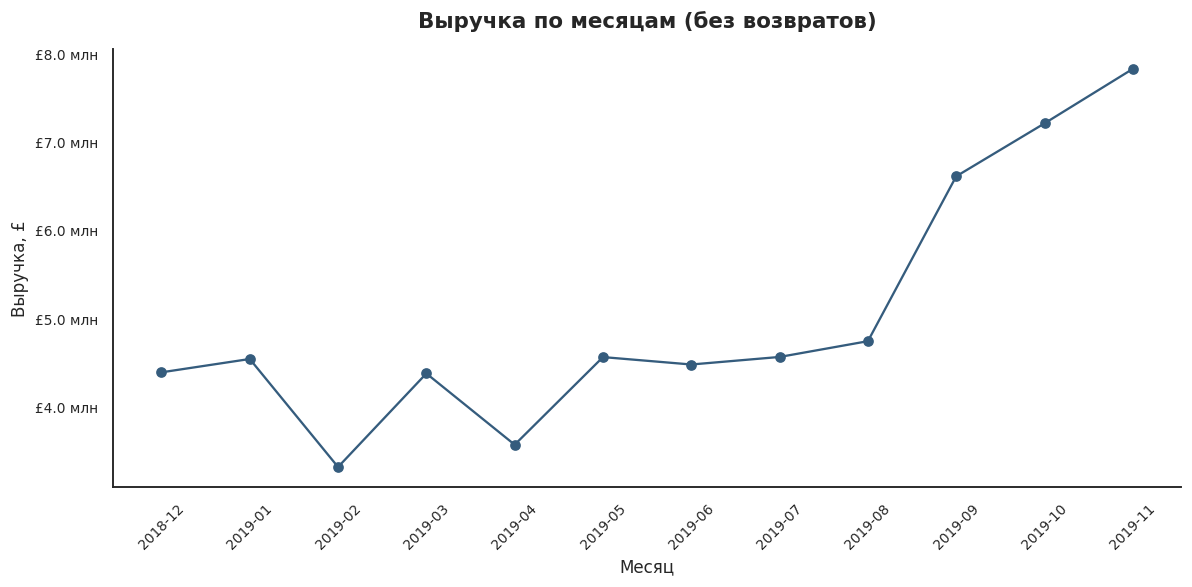

In [ ]:
# денежная динамика по полным месяцам
last_period = sales_df["YearMonth"].max()

monthly_sales = (
    order_agg.loc[order_agg["year_month"] < last_period]
    .groupby("year_month", as_index=False)
    .agg(GrossAmount=("total_amount", "sum"))
    .sort_values("year_month")
)
monthly_sales["Period"] = monthly_sales["year_month"].astype("string")

fig, ax = plt.subplots()
ax.plot(monthly_sales["Period"], monthly_sales["GrossAmount"], color=EDA_BLUE, marker='o')

ax.tick_params(axis="x", rotation=45)
finish_chart(
    ax,
    "Выручка по месяцам (без возвратов)",
    "Месяц",
    "Выручка, £"
)

ax.yaxis.set_major_formatter(FuncFormatter(pounds_compact))
plt.tight_layout()
plt.show()


Среди полных месяцев максимальная сумма продаж зафиксирована в ноябре 2019 года — £7,83 млн, минимальная — в феврале 2019 года, £3,33 млн. С сентября по ноябрь показатель последовательно увеличивался. Одного годового цикла недостаточно, чтобы подтвердить устойчивую сезонность.


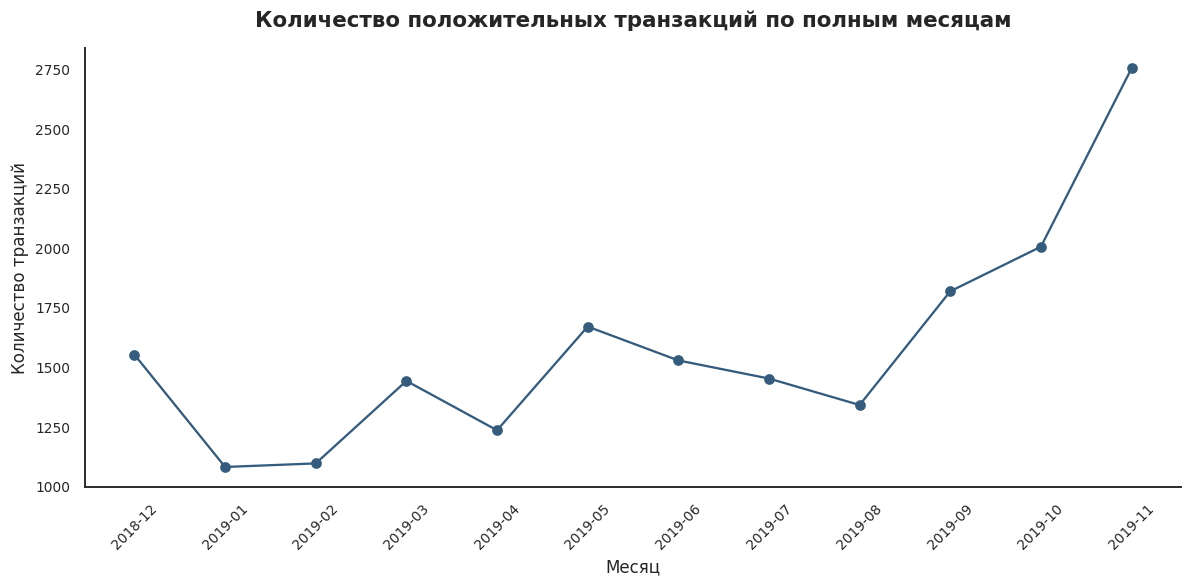

In [ ]:
# динамика количества транзакций по полным месяцам

monthly_orders = (
    order_agg.loc[order_agg["year_month"] < last_period]
    .groupby("year_month", as_index=False)
    .agg(OrderCount=("TransactionNo", "nunique"))
    .sort_values("year_month")
)
monthly_orders["Period"] = monthly_orders["year_month"].astype("string")

fig, ax = plt.subplots()
ax.plot(monthly_orders["Period"], monthly_orders["OrderCount"], color=EDA_BLUE, marker='o')
ax.tick_params(axis="x", rotation=45)
finish_chart(
    ax,
    "Количество положительных транзакций по полным месяцам",
    "Месяц",
    "Количество транзакций"
)
plt.tight_layout()
plt.show()


Максимальное число заказов зафиксировано в ноябре 2019 года — 2 753, минимальное — в январе, 1 081. Одновременный рост суммы продаж и числа заказов наблюдается осенью; его причина данными не устанавливается.


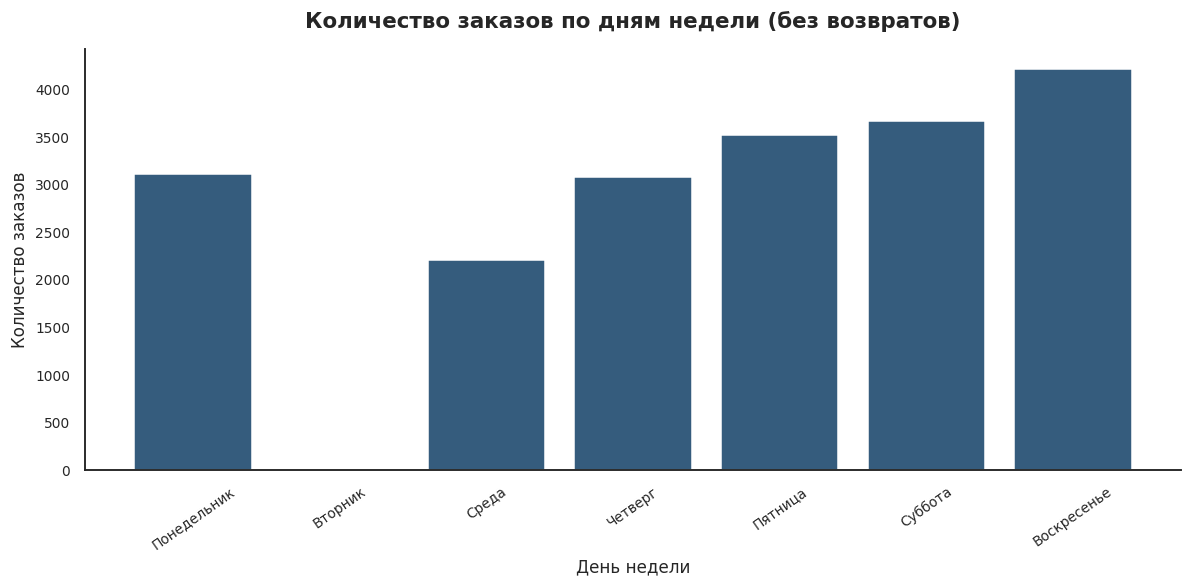

In [ ]:
# распределение транзакций по дням недели

weekday_order = pd.DataFrame({
    "day_of_week": range(7),
    "Day": [
        "Понедельник", "Вторник", "Среда", "Четверг",
        "Пятница", "Суббота", "Воскресенье"
    ]
})

weekday_orders = (
    order_agg.groupby("day_of_week", as_index=False)
    .agg(OrderCount=("TransactionNo", "nunique"))
    .merge(weekday_order, on="day_of_week", how="right")
    .fillna({"OrderCount": 0})
    .sort_values("day_of_week")
)

fig, ax = plt.subplots()
ax.bar(weekday_orders["Day"], weekday_orders["OrderCount"], color=EDA_BLUE)
ax.tick_params(axis="x", rotation=35)
finish_chart(
    ax,
    "Количество заказов по дням недели (без возвратов)",
    "День недели",
    "Количество заказов"
)
plt.tight_layout()
plt.show()


Больше всего заказов приходится на воскресенье — 4 212, меньше всего среди представленных дней — на среду, 2 203. По вторникам транзакций нет; причину этого по имеющимся данным подтвердить нельзя.


## **Шаг 3.2. Сумма и состав заказа**


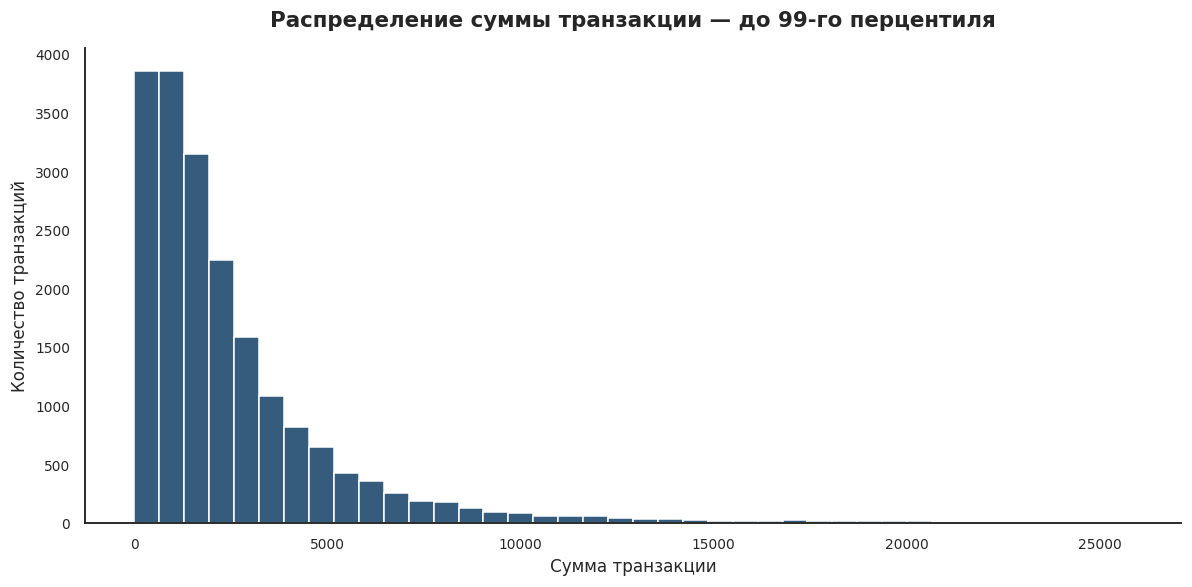

In [ ]:
# Распределение суммы положительной транзакции

order_amount_limit = order_agg["total_amount"].quantile(0.99)
order_amount_for_plot = (
    order_agg.loc[
        order_agg["total_amount"] <= order_amount_limit,
        "total_amount"
    ].sort_values()
)

fig, ax = plt.subplots()
ax.hist(order_amount_for_plot, bins=40, color=EDA_BLUE, edgecolor="white")
finish_chart(
    ax,
    "Распределение суммы транзакции — до 99-го перцентиля",
    "Сумма транзакции",
    "Количество транзакций"
)
plt.tight_layout()
plt.show()


Распределение суммы заказа имеет длинный правый хвост. Медиана равна £1 709,42, 99-й перцентиль — £25 822,64. Для читаемости на графике показаны 99% заказов; оставшийся 1% сохранён в расчётах.


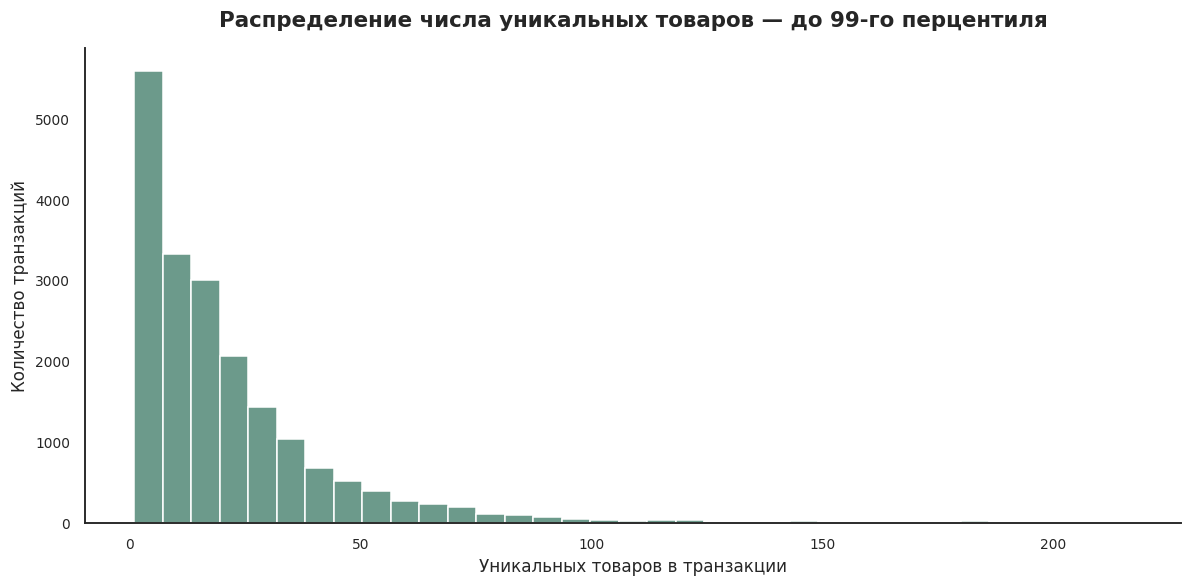

In [ ]:
#Распределение числа уникальных товаров в транзакции

product_count_limit = order_agg["unique_products"].quantile(0.99)
product_count_for_plot = (
    order_agg.loc[
        order_agg["unique_products"] <= product_count_limit,
        "unique_products"
    ].sort_values()
)

fig, ax = plt.subplots()
ax.hist(product_count_for_plot, bins=35, color=EDA_GREEN, edgecolor="white")
finish_chart(
    ax,
    "Распределение числа уникальных товаров — до 99-го перцентиля",
    "Уникальных товаров в транзакции",
    "Количество транзакций"
)
plt.tight_layout()
plt.show()


Медианный заказ содержит 15 уникальных товаров, 75-й перцентиль — 29, 99-й — около 217. Распределение состава заказа также имеет длинный правый хвост.


## **Шаг 3.3. Товары**


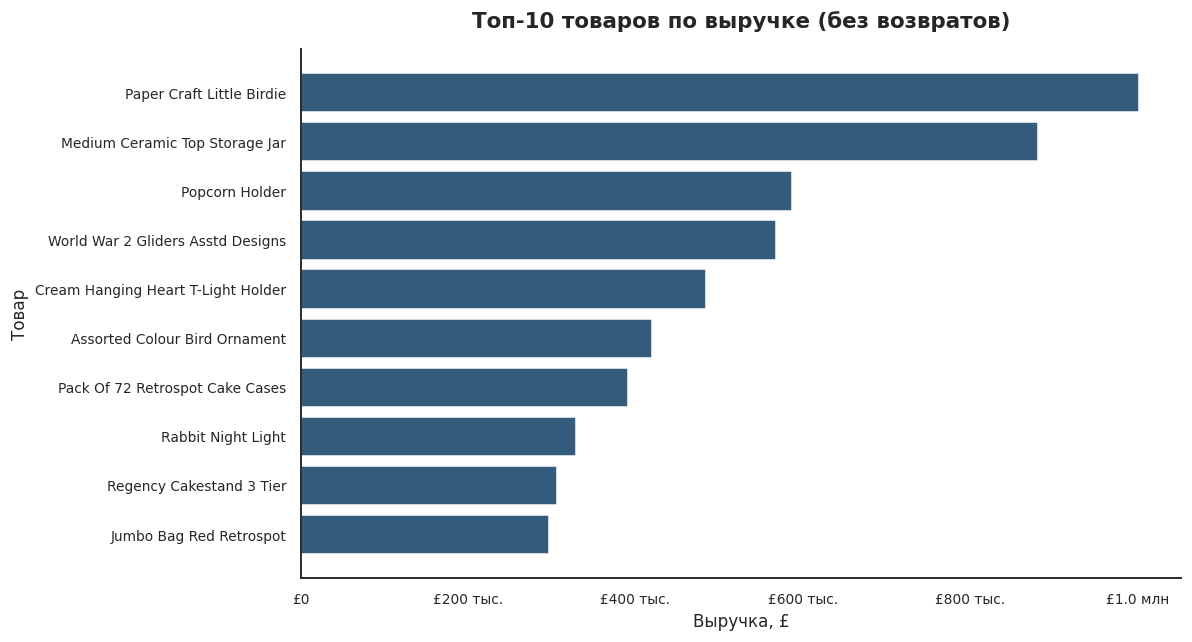

In [ ]:
# единая товарная агрегация положительных операций

product_stats = (
    sales_df.groupby(["ProductNo", "ProductName"], as_index=False)
    .agg(
        GrossAmount=("TotalAmount", "sum"),
        Quantity=("Quantity", "sum"),
        OrderCount=("TransactionNo", "nunique")
    )
)

top_products_amount = (
    product_stats.nlargest(10, "GrossAmount")
    .sort_values("GrossAmount")
)

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(top_products_amount["ProductName"], top_products_amount["GrossAmount"], color=EDA_BLUE)

finish_chart(
    ax,
    "Топ-10 товаров по выручке (без возвратов)",
    "Выручка, £",
    "Товар"
)

ax.xaxis.set_major_formatter(FuncFormatter(pounds_compact))
plt.tight_layout()
plt.show()


`Paper Craft Little Birdie` лидирует с £1,00 млн валовой выручки, но сумма сформирована одной крупной продажей, для которой найден обратный возврат. Рейтинг характеризует валовые продажи, а не устойчивость спроса.


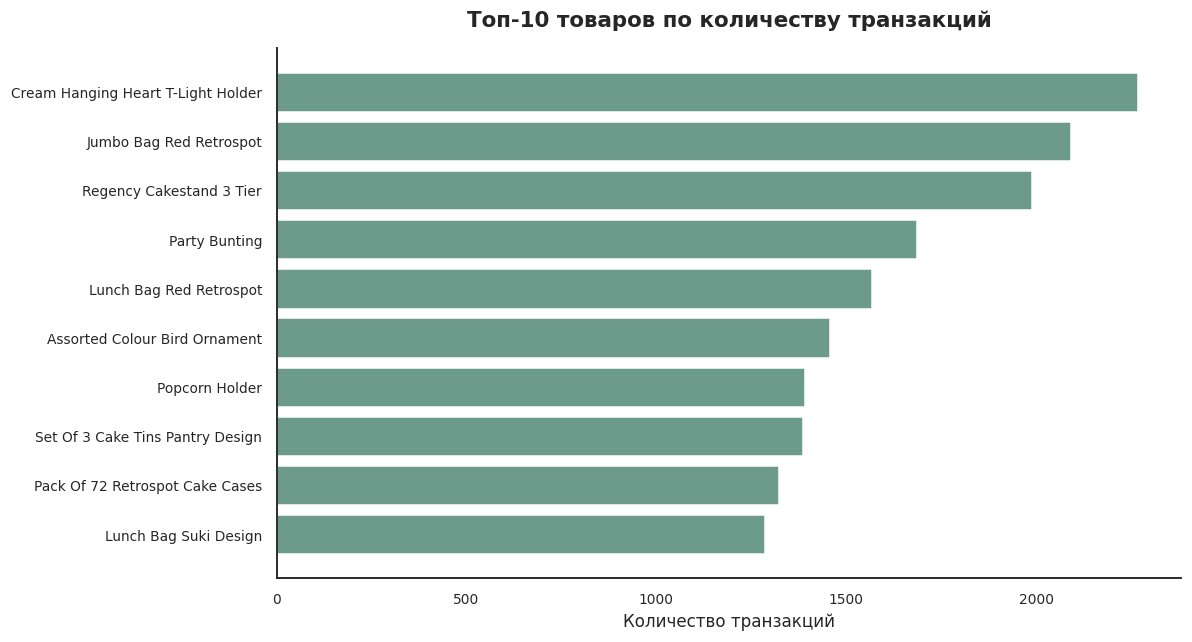

In [ ]:
# товары по частоте присутствия в транзакциях

top_products_orders = (
    product_stats.nlargest(10, "OrderCount")
    .sort_values("OrderCount")
)

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(top_products_orders["ProductName"], top_products_orders["OrderCount"], color=EDA_GREEN)
finish_chart(
    ax,
    "Топ-10 товаров по количеству транзакций",
    "Количество транзакций",
    ""
)
plt.tight_layout()
plt.show()


`Cream Hanging Heart T-Light Holder` встречается в 2 269 заказах — 11,47% всех заказов с продажами. Рейтинг по частоте отличается от рейтинга по выручке.


## **Шаг 3.4. Клиенты**
*
Технический идентификатор `-1` исключён из клиентских распределений.


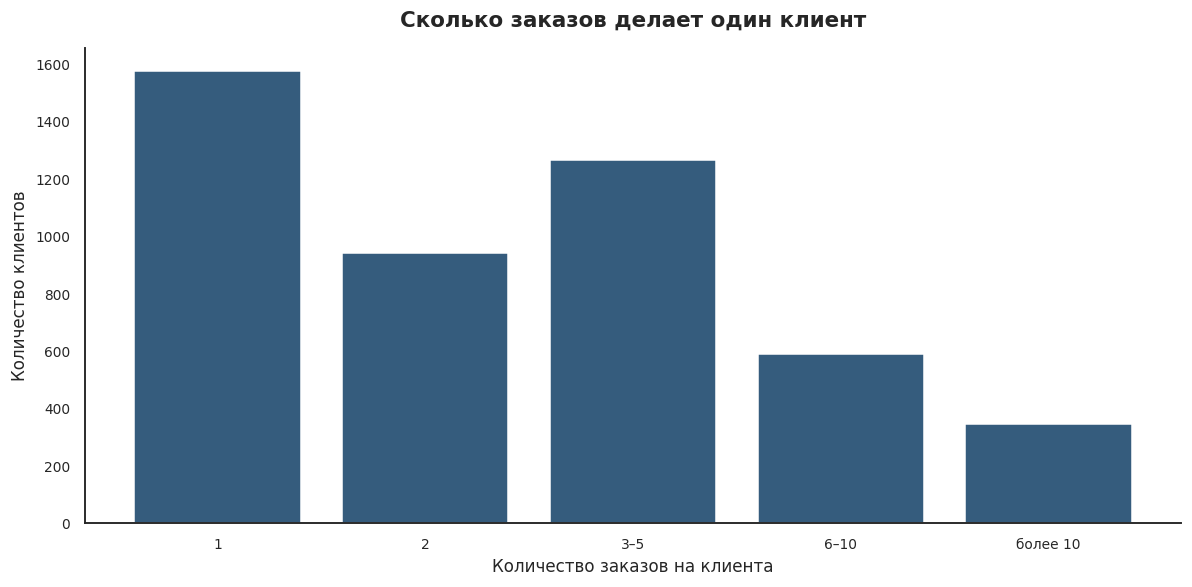

In [ ]:
#  частота положительных транзакций клиентов

customer_stats = (
    order_agg.loc[order_agg["customer_no"] != -1]
    .groupby("customer_no", as_index=False)
    .agg(
        OrderCount=("TransactionNo", "nunique"),
        GrossAmount=("total_amount", "sum"),
        AverageOrder=("total_amount", "mean"),
        FirstDate=("date", "min"),
        LastDate=("date", "max")
    )
)

frequency_labels = ["1", "2", "3–5", "6–10", "более 10"]
customer_stats["FrequencyGroup"] = pd.cut(
    customer_stats["OrderCount"],
    bins=[0, 1, 2, 5, 10, float("inf")],
    labels=frequency_labels
)

customer_frequency = (
    customer_stats["FrequencyGroup"]
    .value_counts()
    .reindex(frequency_labels)
)

fig, ax = plt.subplots()
ax.bar(customer_frequency.index.astype("string"), customer_frequency.values, color=EDA_BLUE)
finish_chart(
    ax,
    "Сколько заказов делает один клиент",
    "Количество заказов на клиента",
    "Количество клиентов"
)
plt.tight_layout()
plt.show()


1 577 клиентов (33,43%) совершили один заказ, 3 141 клиент (66,57%) — более одного. Показатель описывает повторные покупки внутри наблюдаемого периода, но не измеряет удержание без когортного анализа.


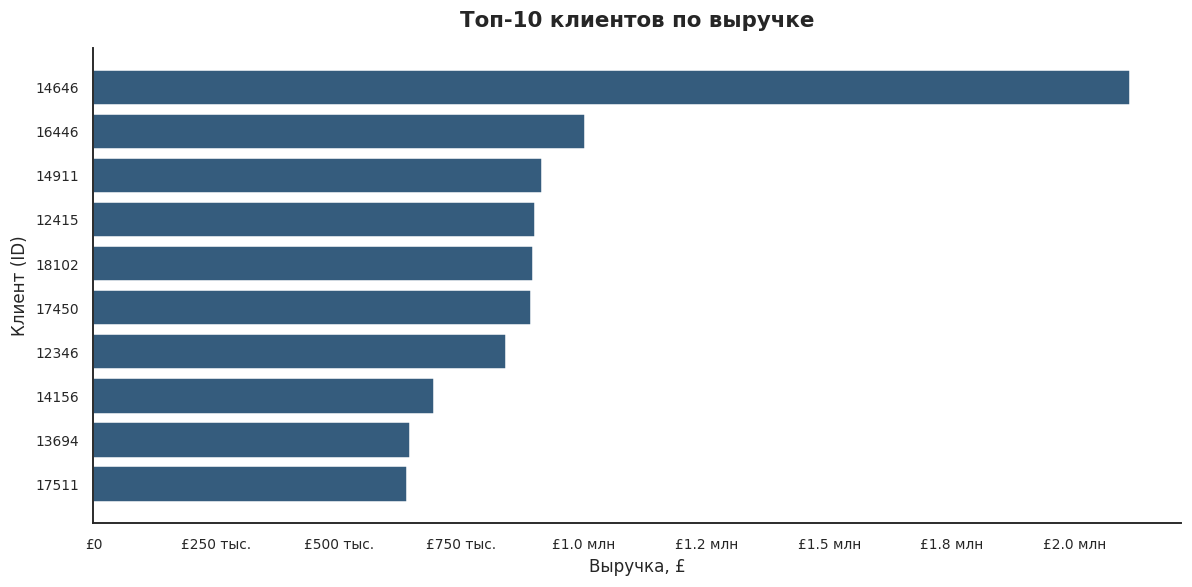

In [ ]:
#  клиенты по сумме положительных операций
top_customers = (
    customer_stats.nlargest(10, "GrossAmount")
    .sort_values("GrossAmount")
)

fig, ax = plt.subplots()
ax.barh(top_customers["customer_no"].astype("string"), top_customers["GrossAmount"], color=EDA_BLUE)
finish_chart(
    ax,
    "Топ-10 клиентов по выручке",
    "Выручка, £",
    "Клиент (ID)"
)

ax.xaxis.set_major_formatter(FuncFormatter(pounds_compact))
plt.tight_layout()
plt.show()


Клиент 14646 лидирует с £2,11 млн валовой выручки и 73 заказами. Верхние 10% клиентов по сумме формируют 59,02% валовой выручки. Это показатель концентрации, а не прибыли или пожизненной ценности клиента.


## **Шаг 3.5. География**


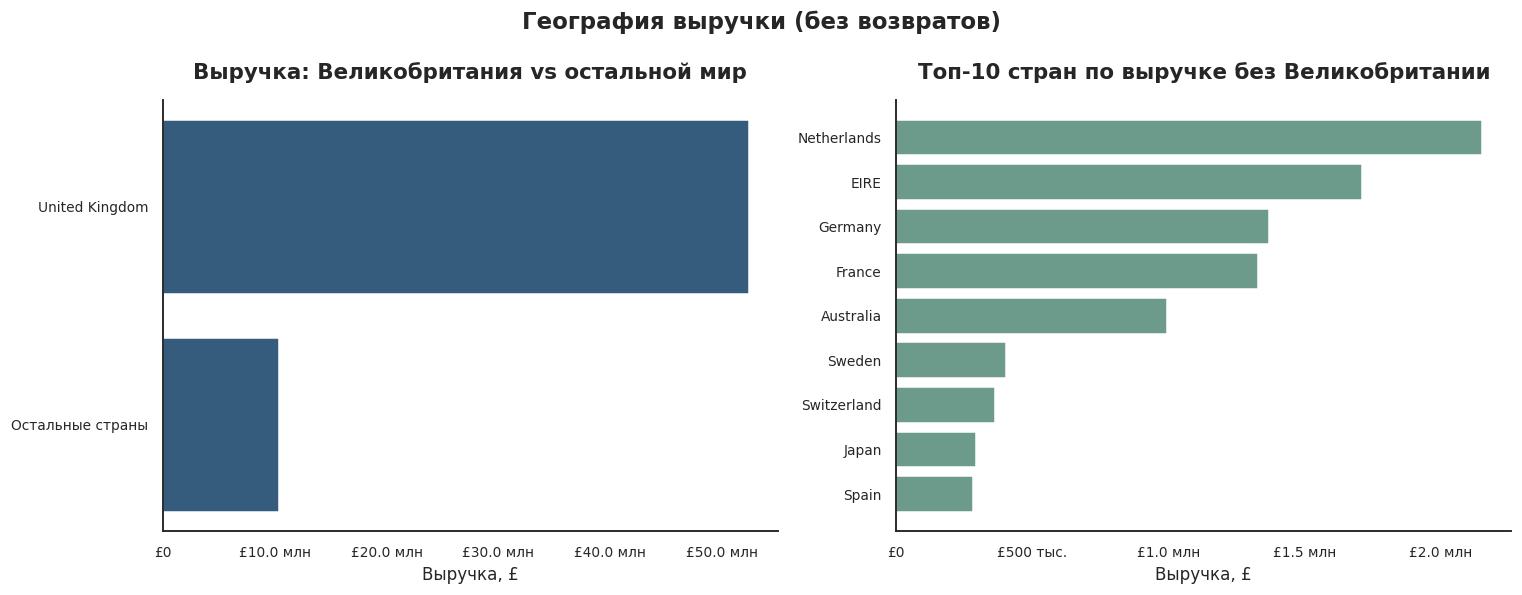

In [ ]:
# страны по сумме положительных операций

country_stats = (
    order_agg.groupby("country", as_index=False)
    .agg(
        GrossAmount=("total_amount", "sum"),
        OrderCount=("TransactionNo", "nunique"),
        AverageOrder=("total_amount", "mean")
    )
)

top_countries_amount = (
    country_stats.nlargest(10, "GrossAmount")
    .sort_values("GrossAmount")
)

uk_vs_other = pd.DataFrame({
    "Market": ["Остальные страны", "United Kingdom"],
    "GrossAmount": [
        country_stats.loc[
            country_stats["country"] != "United Kingdom",
            "GrossAmount"
        ].sum(),
        country_stats.loc[
            country_stats["country"] == "United Kingdom",
            "GrossAmount"
        ].sum()
    ]
}).sort_values("GrossAmount")

top_countries_without_uk = (
    country_stats.loc[country_stats["country"] != "United Kingdom"]
    .nlargest(9, "GrossAmount")
    .sort_values("GrossAmount")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
axes[0].barh(uk_vs_other["Market"], uk_vs_other["GrossAmount"], color=EDA_BLUE)

finish_chart(
    axes[0],
    "Выручка: Великобритания vs остальной мир",
    "Выручка, £",
    ""
)

axes[1].barh(
    top_countries_without_uk["country"],
    top_countries_without_uk["GrossAmount"],
    color=EDA_GREEN
)

finish_chart(
    axes[1],
    "Топ-10 стран по выручке без Великобритании",
    "Выручка, £",
    ""
)

fig.suptitle(
    "География выручки (без возвратов)",
    fontsize=15,
    fontweight="bold"
)

axes[0].xaxis.set_major_formatter(FuncFormatter(pounds_compact))
axes[1].xaxis.set_major_formatter(FuncFormatter(pounds_compact))
plt.tight_layout()
plt.show()


Великобритания формирует £52,35 млн — 83,38% валовой выручки — и 90,49% заказов. Продажи существенно сконцентрированы на одном рынке.


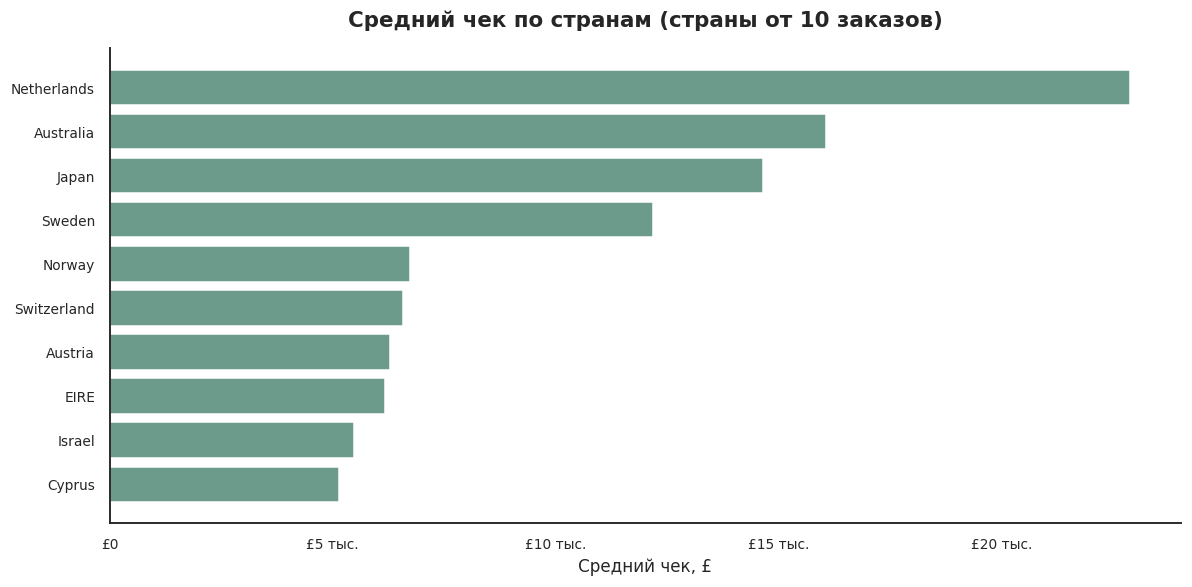

In [ ]:
# средняя сумма транзакции по странам с достаточным числом наблюдений

country_average_filtered = (
    country_stats.loc[country_stats["OrderCount"] >= 10]
    .nlargest(10, "AverageOrder")
    .sort_values("AverageOrder")
)

fig, ax = plt.subplots()
ax.barh(country_average_filtered["country"], country_average_filtered["AverageOrder"], color=EDA_GREEN)

finish_chart(
    ax,
    "Средний чек по странам (страны от 10 заказов)",
    "Средний чек, £",
    ""
)

ax.xaxis.set_major_formatter(FuncFormatter(pounds_compact))
plt.tight_layout()
plt.show()


Среди стран как минимум с 10 заказами максимальный средний чек зафиксирован в Нидерландах — £22 888,87, затем в Австралии — £16 055,06 и Японии — £14 657,77. Порог снижает влияние единичных заказов, но не устраняет различия в составе клиентов и заказов.


## **Шаг 3.6. Возвратные и отменённые операции**

Они анализируются отдельно и не смешиваются с продажами.


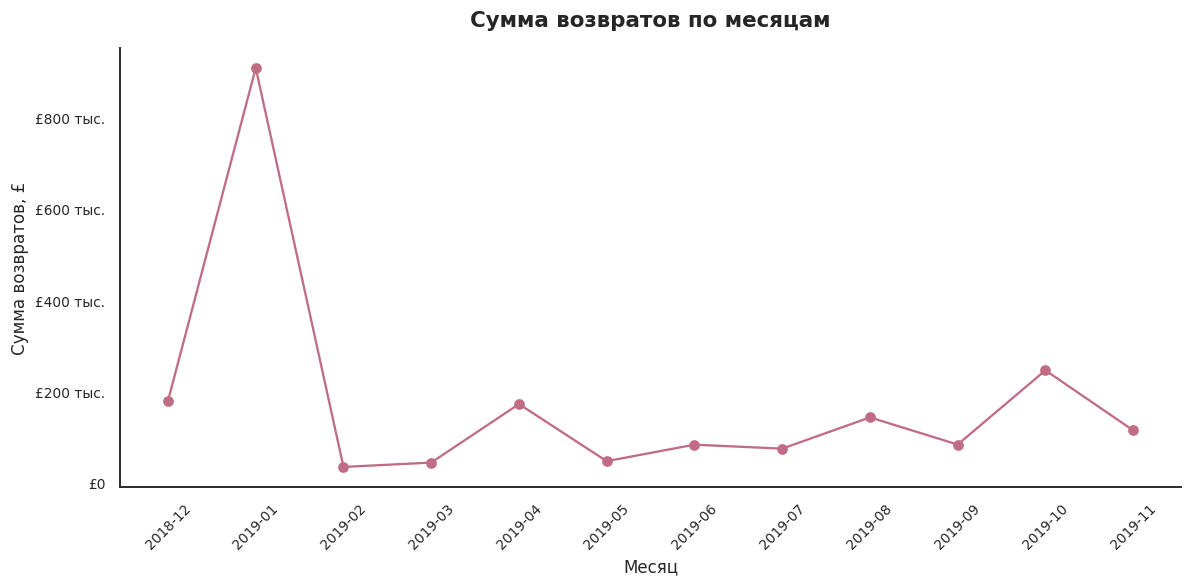

In [ ]:
# сумма возвратных операций по полным месяцам

monthly_returns = (
    return_agg.loc[return_agg["year_month"] < last_period]
    .groupby("year_month", as_index=False)
    .agg(ReturnAmount=("total_return_amount", "sum"))
    .sort_values("year_month")
)
monthly_returns["Period"] = monthly_returns["year_month"].astype("string")

fig, ax = plt.subplots()
ax.plot(monthly_returns["Period"], monthly_returns["ReturnAmount"], color=EDA_ACCENT, marker='o')

ax.tick_params(axis="x", rotation=45)
finish_chart(
    ax,
    "Сумма возвратов по месяцам",
    "Месяц",
    "Сумма возвратов, £"
)

ax.yaxis.set_major_formatter(FuncFormatter(pounds_compact))
plt.tight_layout()
plt.show()


Январь 2019 года выделяется суммой возвратных операций £910,34 тыс. — 34,16% суммы за весь период. Среднее значение по месяцам без учёта отдельных крупных операций было бы вводящим в заблуждение.


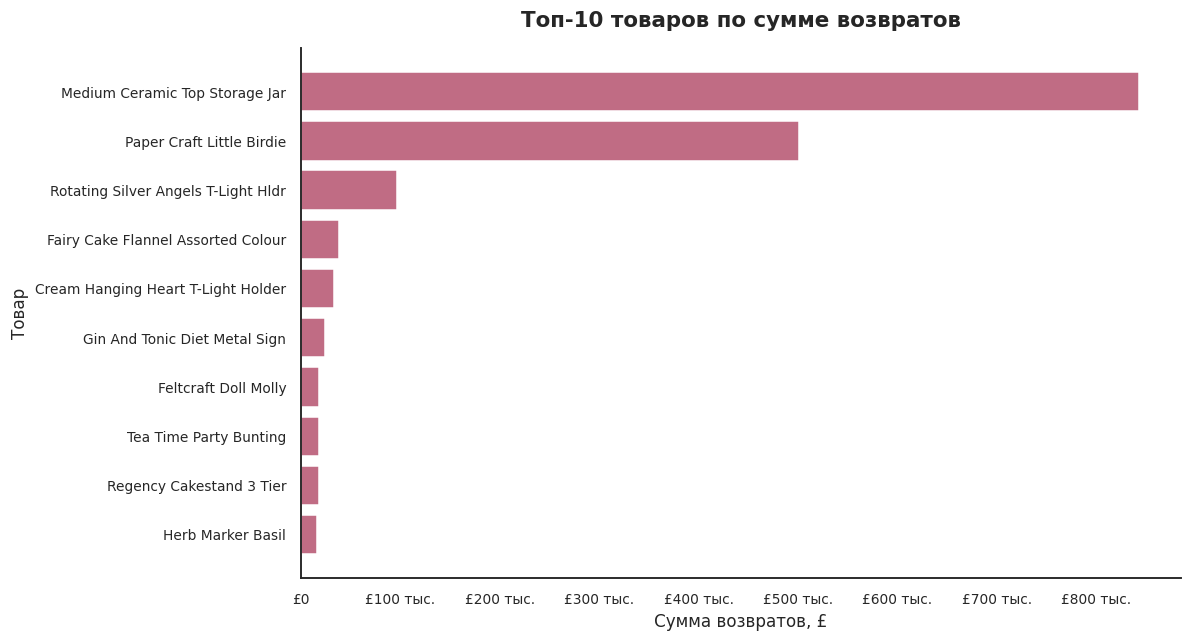

In [ ]:
# товары по сумме возвратных операций

return_product_stats = (
    returns_df.groupby(["ProductNo", "ProductName"], as_index=False)
    .agg(
        ReturnAmount=("ReturnAmount", "sum"),
        ReturnQuantity=("Quantity", lambda values: values.abs().sum()),
        ReturnTransactions=("TransactionNo", "nunique")
    )
)

top_return_products = (
    return_product_stats.nlargest(10, "ReturnAmount")
    .sort_values("ReturnAmount")
)

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(top_return_products["ProductName"], top_return_products["ReturnAmount"], color=EDA_ACCENT)

finish_chart(
    ax,
    "Топ-10 товаров по сумме возвратов",
    "Сумма возвратов, £",
    "Товар"
)

ax.xaxis.set_major_formatter(FuncFormatter(pounds_compact))
plt.tight_layout()
plt.show()


`Medium Ceramic Top Storage Jar` формирует £843,28 тыс. — 31,65% суммы возвратных операций; `Paper Craft Little Birdie` — ещё 18,82%. Сумма возвратов концентрируется в нескольких крупных товарных операциях.


## **Шаг 3.7. Цены и ценовые интервалы**


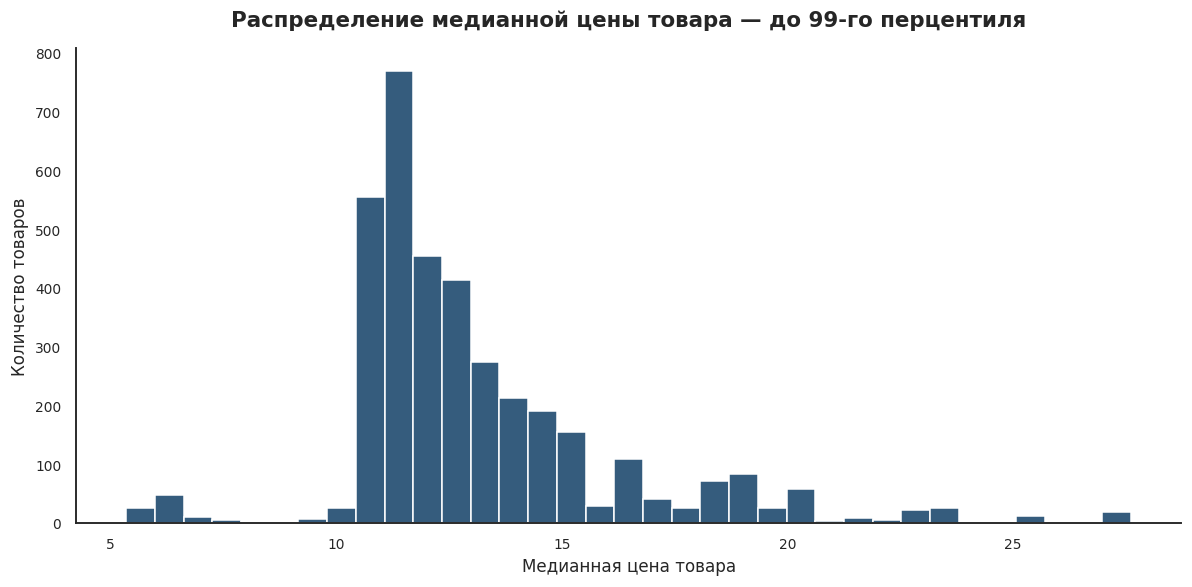

In [ ]:
#  распределение типичной цены товара

representative_product_price = (
    sales_df.groupby(["ProductNo", "ProductName"])["Price"]
    .median()
    .sort_values()
)
price_limit = representative_product_price.quantile(0.99)
price_for_plot = representative_product_price.loc[
    representative_product_price <= price_limit
]

fig, ax = plt.subplots()
ax.hist(price_for_plot, bins=35, color=EDA_BLUE, edgecolor="white")

finish_chart(
    ax,
    "Распределение медианной цены товара — до 99-го перцентиля",
    "Медианная цена товара",
    "Количество товаров"
)
plt.tight_layout()
plt.show()


Среди 3 753 товаров в продажах медианная цена равна £12,25, 99-й перцентиль — £27,62. Для читаемости график ограничен 99-м перцентилем; дорогие позиции сохранены в данных и расчётах.


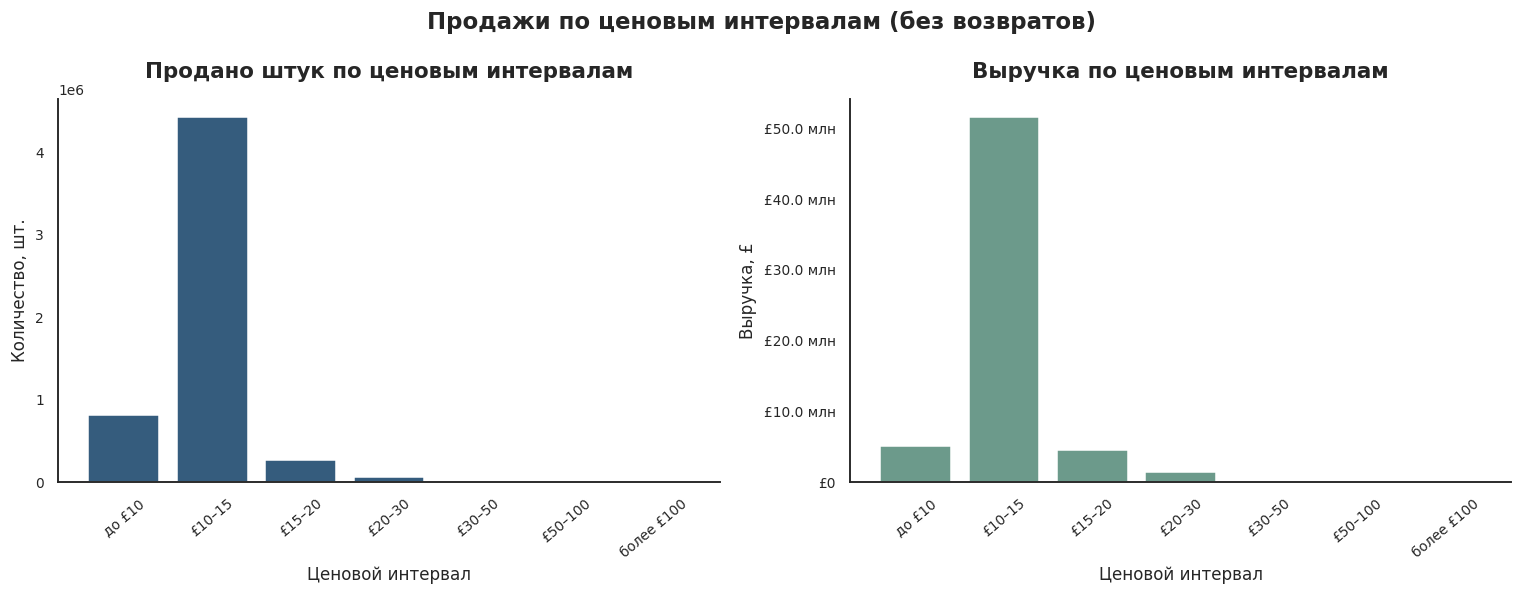

In [ ]:
# количество единиц и денежная сумма по ценовым интервалам

price_labels = [
    "до £10", "£10–15", "£15–20", "£20–30",
    "£30–50", "£50–100", "более £100"
]

sales_with_segment = sales_df.assign(
    PriceSegment=pd.cut(
        sales_df["Price"],
        bins=[0, 10, 15, 20, 30, 50, 100, float("inf")],
        labels=price_labels,
        right=False
    )
)

price_segment_stats = (
    sales_with_segment.groupby("PriceSegment", observed=False, as_index=False)
    .agg(
        Quantity=("Quantity", "sum"),
        GrossAmount=("TotalAmount", "sum")
    )
    .set_index("PriceSegment")
    .reindex(price_labels)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
axes[0].bar(price_segment_stats["PriceSegment"].astype("string"), price_segment_stats["Quantity"], color=EDA_BLUE)

axes[0].tick_params(axis="x", rotation=40)
finish_chart(axes[0], "Продано штук по ценовым интервалам", "Ценовой интервал", "Количество, шт.")

axes[1].bar(price_segment_stats["PriceSegment"].astype("string"), price_segment_stats["GrossAmount"], color=EDA_GREEN)

axes[1].tick_params(axis="x", rotation=40)
finish_chart(axes[1], "Выручка по ценовым интервалам", "Ценовой интервал", "Выручка, £")

fig.suptitle("Продажи по ценовым интервалам (без возвратов)", fontsize=15, fontweight="bold")

axes[1].yaxis.set_major_formatter(FuncFormatter(pounds_compact))
plt.tight_layout()
plt.show()


Интервал £10–15 формирует 79,30% проданных единиц и 82,07% валовой выручки. Это описательная концентрация по выбранным интервалам; она не доказывает причинную связь цены и спроса.


## **Выводы этапа 3**

1. **Динамика.** В наблюдаемом периоде продажи растут с сентября по ноябрь; максимум приходится на ноябрь. Для подтверждения устойчивой сезонности требуется несколько годовых циклов.
2. **Товары.** Лидеры по валовой выручке частично определяются единичными крупными операциями и обратными возвратами. Рейтинг по числу заказов лучше отражает регулярность спроса.
3. **Клиенты.** 33,43% клиентов совершили один заказ за период. Верхние 10% клиентов формируют 59,02% валовой выручки.
4. **География.** На Великобританию приходится 83,38% валовой выручки и 90,49% заказов.
5. **Возвраты.** Два товара формируют 50,46% суммы возвратных операций.
6. **Ценовые интервалы.** Диапазон £10–15 формирует 82,07% валовой выручки.

Результаты описывают структуру операций, но не устанавливают причины наблюдаемых различий.


---
---
---

# **Этап 4. Ключевые выводы и рекомендации**
*   Формирование основных инсайтов по каждому блоку анализа.
*   Разработка практических рекомендаций для увеличения выручки, удержания клиентов и оптимизации ассортимента.

## **ВЫВОДЫ**

Исследование показало, что бизнес‑модель магазина является **двухскоростной**: высокая общая выручка (£60,1 млн неттоза исследуемый период) держится на трёх китах – **британский рынок** (83,4% выручки), **топ‑10% клиентов** (дают 59% оборота) и **ценовой сегмент £10–15** (82% продаж). Такая структура создаёт иллюзию стабильности, но несёт системные риски:

- **Географическая монозависимость** – любой локальный кризис в Великобритании ударит по всему бизнесу.
- **Низкая доля повторных покупок** – 33,4% клиентов сделали только одну покупку за период наблюдения (это не доказывает, что они не вернутся — часть могла купить до/после периода в датасете); потенциал повторных продаж используется не полностью.


- **Скрытые потери от возвратов** – £2,66 млн (4,2% от валовой выручки), при этом 50% суммы возвратов приходится на два товара («Medium Ceramic Top Storage Jar» – 31,6%, «Paper Craft Little Birdie» – 18,8%).
- **Неиспользованная возможность** – международные рынки (Нидерланды, Австралия, Япония) показывают средний чек в **5–7 раз выше**, чем в UK, но их доля в обороте ничтожна.



## **Рекомендации**

Для устойчивого роста необходимо  диверсифицировать географию, повысить удержание «одноразовых» клиентов и снизить возвратные потери, одновременно усиливая кросс‑продажи в уже работающих ценовых нишах.

----
  Действия которые помогут увеличить выручку, снизить потери и сделать бизнес более устойчивым:

- **Гипотеза для проверки: международный рост**. В Нидерландах, Австралии и Японии средний чек в 5–7 раз выше, чем в Великобритании — правда, это может объясняться и оптовым характером части этих заказов, а не спросом в рознице (стоит проверить отдельно). Если гипотеза подтвердится, пробные рекламные кампании и упрощение доставки в эти страны — разумный способ снизить зависимость от одного рынка.



- **Гипотеза для проверки: стимулирование повторной покупки**. Каждый третий покупатель (33%) за период наблюдения сделал только одну покупку. Стоит A/B-тестом проверить гипотезу, что скидка 10–15% на второй заказ увеличивает долю повторных покупок — без теста нельзя утверждать, что это сработает.



- **Возврат товаров**. Две позиции – «Medium Ceramic Top Storage Jar» и «Paper Craft Little Birdie» – дают половину всех возвратов (£2,66 млн суммарно, из них половина — эти два товара). Причина возвратов данными не установлена (это может быть качество, описание, упаковка или, например, характер использования товара) — нужно отдельное исследование причин, прежде чем говорить о конкретной экономии.



- **Внимание крупным клиентам**. Всего 10% покупателей приносят 60% выручки. Введите для них персональные предложения и ранний доступ к новинкам – это снизит риск их ухода к конкурентам.

 - **Спад в январе и феврале.** В эти месяцы продажи падают в 2,5 раза по сравнению с ноябрём. Запускайте сезонные акции и используйте историю покупок для персонализированных предложений.

 ---



**Ограничения**

- отсутствуют себестоимость и маржинальность;
- нет данных о маркетинговых расходах;
- период не позволяет надёжно подтвердить сезонность;
- описательный анализ не доказывает причины поведения клиентов.

----
----
----